<a href="https://colab.research.google.com/github/muliawhd/Data-mining/blob/main/EDA_Otomatis_CSV_ke_Laporan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Auto-EDA Notebook — dari Cleaning sampai Laporan Word

Notebook ini melakukan **Exploratory Data Analysis (EDA) end-to-end** untuk *CSV apa pun*:

| Tahap | Isi |
|---|---|
| 1 | Upload CSV lokal (deteksi otomatis delimiter & encoding) |
| 2 | Gambaran umum dataset |
| 3 | **Data cleaning** otomatis (nama kolom, spasi, token missing, duplikat, konversi tipe angka/tanggal, konsistensi huruf, missing value, outlier) |
| 4 | Profil & **interpretasi otomatis per kolom** (numerik, kategorikal, tanggal, teks, ID, konstan) |
| 5 | Visualisasi univariat, bivariat (korelasi, asosiasi, scatter, boxplot), deret waktu, analisis target |
| 6 | **Laporan `.docx`** berisi ringkasan, log cleaning, grafik + interpretasi setiap kolom, hubungan antar variabel, kesimpulan & rekomendasi |

**Cara pakai:** (1) jalankan sel instalasi → (2) atur `CONFIG` bila perlu (semua sudah punya default) → (3) *Run All* → (4) upload CSV saat diminta.
Hasil tersimpan di folder `eda_output/` (laporan, CSV bersih, semua gambar).

In [ ]:
# ── Instalasi otomatis library yang belum ada ──────────────────────────────
import sys, subprocess, importlib
for pkg, mod in [("pandas","pandas"), ("numpy","numpy"), ("matplotlib","matplotlib"), ("python-docx","docx")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, re, io, csv, json, shutil, warnings, datetime as dt
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "axes.titlesize": 11, "axes.titleweight": "bold",
})
OUT_DIR = "eda_output"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("✅ Siap. pandas", pd.__version__)

✅ Siap. pandas 2.2.3


## ⚙️ Konfigurasi
Semua opsi punya nilai default yang masuk akal. Cukup ubah seperlunya — **notebook tetap jalan tanpa mengubah apa pun**.

In [ ]:
CONFIG = dict(
    # ── Input ──────────────────────────────────────────────────────────────
    CSV_PATH = None,          # None = upload lewat dialog. Atau isi path, mis. "data/penjualan.csv"
    SEP = None,               # None = deteksi otomatis (",", ";", tab, "|")
    ENCODING = None,          # None = coba utf-8, cp1252, latin-1 otomatis
    DATASET_NAME = None,      # None = pakai nama file
    TARGET = None,            # (opsional) nama kolom target/label untuk analisis khusus
    DATE_COL = None,          # (opsional) kolom tanggal utama; None = pakai kolom tanggal pertama
    # ── Cleaning ───────────────────────────────────────────────────────────
    STANDARDIZE_COLUMNS = True,   # ubah nama kolom jadi snake_case
    MISSING_TOKENS = ["", "na", "n/a", "nan", "null", "none", "-", "--", "?", "tidak ada", "tidak tersedia",
                      "kosong", "missing", "#n/a", "unknown", "undefined"],
    DROP_DUPLICATES = True,
    DAYFIRST = True,              # True: 05/03/2024 dibaca 5 Maret (format Indonesia)
    NUMERIC_PARSE_MIN = 0.90,     # kolom teks dikonversi ke angka bila >=90% nilainya valid
    DROP_COL_MISSING_PCT = 60,    # kolom dengan missing > 60% dibuang
    MISSING_STRATEGY = "impute",  # "impute" | "drop_rows" | "none"
    NUM_IMPUTE = "median",        # "median" | "mean"
    CAT_IMPUTE = "mode",          # "mode" | "unknown"
    OUTLIER_ACTION = "flag",      # "flag" (hanya tandai) | "cap" (winsorize ke batas IQR) | "remove" | "none"
    IQR_K = 1.5,
    # ── Klasifikasi tipe kolom ─────────────────────────────────────────────
    DISCRETE_MAX = 8,             # integer dengan <=8 nilai unik dianggap kategorikal (mis. rating 1-5)
    CAT_MAX = 50,                 # teks dengan <=50 nilai unik dianggap kategorikal
    ID_UNIQUE_RATIO = 0.95,       # rasio unik >=95% -> kandidat kolom ID
    # ── Visualisasi & analisis ─────────────────────────────────────────────
    TOP_N = 10,                   # jumlah kategori teratas yang ditampilkan
    CORR_METHOD = "pearson",      # "pearson" | "spearman"
    MAX_ASSOC_COLS = 25,          # batas kolom untuk matriks hubungan antar variabel
    MAX_ASSOC_CARD = 30,          # kategorikal dengan >30 kategori tidak diikutkan dalam asosiasi
    SHOW_PLOTS = True,
    FIG_DPI = 110,
    # ── Laporan ────────────────────────────────────────────────────────────
    REPORT_TITLE = "Laporan Exploratory Data Analysis",
    AUTHOR = "",
)
print("Konfigurasi dimuat.")

Konfigurasi dimuat.


## 1️⃣ Upload CSV

In [ ]:
# Di Google Colab: dialog upload muncul otomatis.
# Di Jupyter lokal / VS Code: tombol "Upload" (ipywidgets) muncul — pilih file, lalu lanjut ke sel berikutnya.
# Alternatif: isi CONFIG["CSV_PATH"] dengan path file.
UPLOADED = {}
uploader = None
if CONFIG["CSV_PATH"]:
    print("Memakai CSV_PATH:", CONFIG["CSV_PATH"])
elif "google.colab" in sys.modules:
    from google.colab import files
    UPLOADED = files.upload()
else:
    try:
        import ipywidgets as widgets
        uploader = widgets.FileUpload(accept=".csv,.txt,.tsv", multiple=False, description="Pilih CSV")
        display(uploader)
        print("⬆️  Klik tombol, pilih file CSV, lalu jalankan sel berikutnya.")
    except ImportError:
        print("ipywidgets belum terpasang. Jalankan: pip install ipywidgets  — atau isi CONFIG['CSV_PATH'].")

Saving dataset_ump_lengkap_2015_2025.csv to dataset_ump_lengkap_2015_2025.csv


In [ ]:
def _get_input():
    if CONFIG["CSV_PATH"]:
        with open(CONFIG["CSV_PATH"], "rb") as f:
            return os.path.basename(CONFIG["CSV_PATH"]), f.read()
    if UPLOADED:
        name = next(iter(UPLOADED)); return name, UPLOADED[name]
    if uploader is not None and uploader.value:
        v = uploader.value
        item = v[0] if isinstance(v, (list, tuple)) else next(iter(v.values()))
        return item["name"], bytes(item["content"])
    raise RuntimeError("Belum ada file. Upload CSV terlebih dahulu (atau isi CONFIG['CSV_PATH']).")

def read_csv_bytes(raw):
    sample = raw[:30000].decode("utf-8", errors="ignore")
    sep = CONFIG["SEP"]
    if sep is None:
        try: sep = csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except Exception: sep = ","
    encs = [CONFIG["ENCODING"]] if CONFIG["ENCODING"] else ["utf-8-sig", "utf-8", "cp1252", "latin-1"]
    last = None
    for enc in encs:
        try:
            d = pd.read_csv(io.BytesIO(raw), sep=sep, encoding=enc, low_memory=False, on_bad_lines="skip")
            return d, sep, enc
        except UnicodeDecodeError as e:
            last = e
    raise last

FILE_NAME, RAW = _get_input()
df_raw, SEP_USED, ENC_USED = read_csv_bytes(RAW)
DATASET_NAME = CONFIG["DATASET_NAME"] or os.path.splitext(FILE_NAME)[0]
print(f"✅ '{FILE_NAME}' dimuat — {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom  (delimiter: {SEP_USED!r}, encoding: {ENC_USED})")
display(df_raw.head())

✅ 'dataset_ump_lengkap_2015_2025.csv' dimuat — 374 baris × 15 kolom  (delimiter: ',', encoding: utf-8-sig)


,Tahun,Provinsi_Kabupaten,UMR_UMP,Inflasi,PDRB_Per_Kapita,Pertumbuhan_PDRB,Tingkat_Pengangguran_Terbuka,IPM,Jumlah_Penduduk,Persentase_Penduduk_Miskin,PAD,Nilai_Investasi,IHK,Jumlah_Industri,Jumlah_Tenaga_Kerja
0,2015,Aceh,2384762,3.14,57373155,5.60,4.84,71.68,19684130,7.11,6411852,8822960,100.0,7583,12794684
1,2016,Aceh,2505670,1.89,60131292,4.81,4.83,72.08,19920339,6.91,8552215,11647205,102.5,7734,12948220
2,2017,Aceh,2742876,4.30,61986871,3.94,4.26,72.48,20159383,6.71,7602607,14608702,105.0,7889,13103598
3,2018,Aceh,2908006,2.26,69006028,6.35,5.03,72.88,20401296,6.51,9462972,15966608,107.5,8047,13260842
4,2019,Aceh,3054065,2.35,71551652,5.68,4.41,73.28,20646111,6.31,4315314,14515098,110.0,8208,13419972


## 2️⃣ Gambaran Umum Dataset (data mentah)

In [ ]:
overview = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(2),
    "unik": df_raw.nunique(),
    "contoh": [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None for c in df_raw.columns],
})
display(overview)
print(f"Memori: {df_raw.memory_usage(deep=True).sum()/1024**2:.2f} MB | Baris duplikat: {int(df_raw.duplicated().sum()):,}")

,dtype,non_null,missing,missing_%,unik,contoh
Tahun,int64,374,0,0.0,11,2015
Provinsi_Kabupaten,object,374,0,0.0,34,Aceh
UMR_UMP,int64,374,0,0.0,373,2384762
Inflasi,float64,374,0,0.0,246,3.14
PDRB_Per_Kapita,int64,374,0,0.0,374,57373155
Pertumbuhan_PDRB,float64,374,0,0.0,239,5.6
Tingkat_Pengangguran_Terbuka,float64,374,0,0.0,283,4.84
IPM,float64,374,0,0.0,345,71.68
Jumlah_Penduduk,int64,374,0,0.0,374,19684130
Persentase_Penduduk_Miskin,float64,374,0,0.0,302,7.11


Memori: 0.06 MB | Baris duplikat: 0


## 3️⃣ Data Cleaning
Urutan: standarisasi nama kolom → trim spasi & token missing → hapus baris/kolom kosong → hapus duplikat → konversi tipe (angka berformat `Rp 1.250.000`, `12,5%`, tanggal Indonesia) → samakan huruf kategori → deteksi tipe kolom → buang kolom terlalu kosong → tangani missing → tangani outlier.
Setiap langkah dicatat dan masuk ke laporan.

In [ ]:
# ── Helper: formatting angka gaya Indonesia ────────────────────────────────
def fmt(x, d=2):
    if x is None: return "-"
    try:
        if pd.isna(x): return "-"
    except Exception: pass
    if isinstance(x, (int, np.integer)) or (isinstance(x, (float, np.floating)) and float(x).is_integer() and abs(x) < 1e15):
        s = f"{int(x):,}"
    else:
        x = float(x)
        s = f"{x:.4g}" if (x != 0 and abs(x) < 0.01) else f"{x:,.{d}f}"
    return s.replace(",", "§").replace(".", ",").replace("§", ".")

def is_textlike(s):
    return s.dtype == object or pd.api.types.is_string_dtype(s)

def std_name(n):
    out = re.sub(r"[^0-9a-zA-Z]+", "_", str(n)).strip("_").lower()
    return out or "kolom"

# ── Helper: konversi cerdas teks -> angka ──────────────────────────────────
_CUR = re.compile(r"(?i)(rp\.?|idr|usd|eur|us\$|\$|€|£|¥|%|\s)")
_THOUSAND_DOT = re.compile(r"[-+]?[1-9]\d{0,2}(\.\d{3})+")
def _conv_num(v, dot_thousands=False):
    s = _CUR.sub("", v)
    if s == "": return np.nan
    neg = False
    if s.startswith("(") and s.endswith(")"): s, neg = s[1:-1], True
    if not re.fullmatch(r"[-+]?[\d.,]+(e[-+]?\d+)?", s, flags=re.I): return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".") if s.rfind(",") > s.rfind(".") else s.replace(",", "")
    elif "," in s:
        s = s.replace(",", "") if re.fullmatch(r"[-+]?\d{1,3}(,\d{3})+", s) else s.replace(",", ".")
    elif s.count(".") > 1 or (dot_thousands and "." in s):
        s = s.replace(".", "")
    try: x = float(s)
    except ValueError: return np.nan
    return -x if neg else x

def smart_to_numeric(s):
    nn = s.dropna().astype(str)
    if nn.empty: return None, 0
    if (nn.str.match(r"^0\d+$")).mean() > 0.3: return None, 0     # kode berawalan 0 (kode pos, telepon) -> bukan angka
    # Titik tunggal = pemisah ribuan (gaya Indonesia, mis. "Rp 58.899") bila SEMUA nilai bertitik berpola kelipatan 3 digit
    dotted = nn[nn.str.contains(r"\.", regex=True) & ~nn.str.contains(",", regex=False)].map(lambda v: _CUR.sub("", v))
    dot_thousands = len(dotted) > 0 and bool(dotted.map(lambda v: bool(_THOUSAND_DOT.fullmatch(v))).all())
    mapping = {v: _conv_num(v, dot_thousands) for v in nn.unique()}
    ok = nn.map(mapping).notna().mean()
    if ok < CONFIG["NUMERIC_PARSE_MIN"]: return None, 0
    out = s.map(lambda v: mapping.get(str(v), np.nan) if pd.notna(v) else np.nan).astype(float)
    return out, int(s.notna().sum() - out.notna().sum())

# ── Helper: konversi cerdas teks -> tanggal (termasuk nama bulan Indonesia) ─
ID_MONTHS = {"januari":"January","februari":"February","maret":"March","april":"April","mei":"May","juni":"June","juli":"July",
             "agustus":"August","september":"September","oktober":"October","november":"November","desember":"December",
             "agu":"Aug","okt":"Oct","des":"Dec","jan":"Jan","feb":"Feb","mar":"Mar","apr":"Apr","jun":"Jun","jul":"Jul","sep":"Sep","nov":"Nov"}
_ID_RE = re.compile(r"\b(" + "|".join(sorted(ID_MONTHS, key=len, reverse=True)) + r")\b", re.I)
DATE_PAT = re.compile(r"\d{1,4}[-/.]\d{1,2}[-/.]\d{1,4}|\d{1,2}\s+[A-Za-z]{3,9}\s+\d{2,4}|[A-Za-z]{3,9}\s+\d{1,2},?\s+\d{4}")

def smart_to_datetime(s):
    nn = s.dropna().astype(str)
    if nn.empty: return None, 0
    samp = nn.sample(min(len(nn), 200), random_state=0)
    if samp.map(lambda v: bool(DATE_PAT.search(v))).mean() < 0.8: return None, 0
    s2 = s.map(lambda v: _ID_RE.sub(lambda m: ID_MONTHS[m.group(1).lower()], v) if isinstance(v, str) else v)
    try:    parsed = pd.to_datetime(s2, errors="coerce", dayfirst=CONFIG["DAYFIRST"], format="mixed")
    except (TypeError, ValueError): parsed = pd.to_datetime(s2, errors="coerce", dayfirst=CONFIG["DAYFIRST"])
    if parsed.notna().sum() / max(s.notna().sum(), 1) < 0.9: return None, 0
    return parsed, int(s.notna().sum() - parsed.notna().sum())

# ── Helper: klasifikasi tipe kolom ─────────────────────────────────────────
ID_HINT = re.compile(r"(^|_)(id|uuid|kode|code|no|nomor|number|key|index|idx)($|_)", re.I)
BOOL_TOKENS = {"true","false","yes","no","ya","tidak","y","n","t","f","0","1","0.0","1.0","ya.","laki-laki","perempuan","male","female"}

def infer_type(s, name):
    nn = s.dropna(); n = len(nn)
    if n == 0: return "empty"
    nu = nn.nunique()
    if pd.api.types.is_datetime64_any_dtype(s): return "constant" if nu <= 1 else "datetime"
    if nu <= 1: return "constant"
    if pd.api.types.is_bool_dtype(s): return "boolean"
    if pd.api.types.is_numeric_dtype(s):
        if nu == 2: return "boolean"
        isint = bool(np.all(np.mod(nn.astype(float), 1) == 0))
        if isint and nu / n >= CONFIG["ID_UNIQUE_RATIO"] and n > 20 and (ID_HINT.search(name) or nn.is_monotonic_increasing):
            return "id"
        if isint and nu <= CONFIG["DISCRETE_MAX"] and n >= nu * 5: return "categorical"
        return "numeric"
    low = set(nn.astype(str).str.lower().str.strip().unique())
    if nu == 2 and low <= BOOL_TOKENS: return "boolean"
    avg_len = nn.astype(str).str.len().mean(); ratio = nu / n
    if ratio >= CONFIG["ID_UNIQUE_RATIO"] and n > 20: return "id" if avg_len <= 32 else "text"
    if avg_len > 50 and ratio > 0.5: return "text"
    if nu <= CONFIG["CAT_MAX"] or ratio <= 0.5: return "categorical"
    return "text" if avg_len > 25 else "categorical"

TYPE_LABEL = {"numeric":"numerik", "categorical":"kategorikal", "boolean":"biner", "datetime":"tanggal/waktu",
              "text":"teks bebas", "id":"identifier", "constant":"konstan", "empty":"kosong"}
print("Helper cleaning siap.")

Helper cleaning siap.


In [ ]:
cleaning_log = []
def log(msg):
    cleaning_log.append(msg); print("  •", msg)

df = df_raw.copy()
orig_shape = df.shape
dup_n = 0
print("🧹 Proses cleaning:")

# 1) Nama kolom
col_rename = {}
if CONFIG["STANDARDIZE_COLUMNS"]:
    new, seen = [], {}
    for c in df.columns:
        n = std_name(c)
        if n in seen: seen[n] += 1; n = f"{n}_{seen[n]}"
        else: seen[n] = 0
        new.append(n)
    col_rename = {o: n for o, n in zip(df.columns, new) if str(o) != n}
    df.columns = new
    if col_rename: log(f"Nama kolom distandarkan menjadi snake_case ({len(col_rename)} kolom diubah).")

TARGET = std_name(CONFIG["TARGET"]) if (CONFIG["TARGET"] and CONFIG["STANDARDIZE_COLUMNS"]) else CONFIG["TARGET"]
DATE_COL_CFG = std_name(CONFIG["DATE_COL"]) if (CONFIG["DATE_COL"] and CONFIG["STANDARDIZE_COLUMNS"]) else CONFIG["DATE_COL"]

# 2) Trim spasi & token missing
tokens = {t.lower() for t in CONFIG["MISSING_TOKENS"]}
n_tok = 0; n_trim = 0
for c in df.columns:
    if not is_textlike(df[c]): continue
    s = df[c].astype(object)
    s2 = s.map(lambda v: re.sub(r"\s+", " ", v).strip() if isinstance(v, str) else v)
    n_trim += int(((s != s2) & s.notna()).sum())
    mask = s2.map(lambda v: isinstance(v, str) and v.lower() in tokens)
    n_tok += int(mask.sum())
    df[c] = s2.mask(mask, np.nan)
if n_trim: log(f"Spasi berlebih dirapikan pada {n_trim:,} sel.")
if n_tok: log(f"{n_tok:,} sel berisi token kosong (mis. 'N/A', '-', 'null') diubah menjadi missing value.")

# 3) Baris/kolom kosong total
empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    df = df.drop(columns=empty_cols); log(f"Kolom kosong total dibuang: {', '.join(empty_cols)}.")
r0 = len(df); df = df.dropna(how="all").reset_index(drop=True)
if r0 - len(df): log(f"{r0-len(df):,} baris kosong total dibuang.")

# 4) Duplikat
dup_n = int(df.duplicated().sum())
if dup_n and CONFIG["DROP_DUPLICATES"]:
    df = df.drop_duplicates().reset_index(drop=True); log(f"{dup_n:,} baris duplikat dihapus.")
elif dup_n: log(f"Ditemukan {dup_n:,} baris duplikat (tidak dihapus sesuai konfigurasi).")
else: log("Tidak ditemukan baris duplikat.")

# 5) Konversi tipe
for c in list(df.columns):
    if not is_textlike(df[c]): continue
    conv, bad = smart_to_numeric(df[c])
    if conv is not None:
        df[c] = conv
        log(f"Kolom '{c}': teks → numerik" + (f" ({bad:,} nilai tak valid → missing)." if bad else "."))
        continue
    conv, bad = smart_to_datetime(df[c])
    if conv is not None:
        df[c] = conv
        log(f"Kolom '{c}': teks → tanggal/waktu" + (f" ({bad:,} nilai tak valid → missing)." if bad else "."))

# 6) Seragamkan huruf pada kategori (mis. 'jakarta' / 'Jakarta' / 'JAKARTA')
for c in df.columns:
    if not is_textlike(df[c]): continue
    nn = df[c].dropna().astype(str)
    if 0 < nn.nunique() <= 200 and nn.nunique() / max(len(nn), 1) < 0.5:
        low = nn.str.lower()
        if low.nunique() < nn.nunique():
            canon = nn.groupby(low).agg(lambda x: x.value_counts().index[0])
            before = nn.nunique()
            df[c] = df[c].map(lambda v: canon[str(v).lower()] if pd.notna(v) else v)
            log(f"Kolom '{c}': variasi huruf besar/kecil disatukan ({before} → {df[c].nunique()} kategori).")

# 7) Deteksi tipe
col_types = {c: infer_type(df[c], c) for c in df.columns}
discrete_numeric_cols = [c for c in df.columns if col_types[c] == "categorical" and pd.api.types.is_numeric_dtype(df[c])]
if TARGET and TARGET not in df.columns:
    print(f"⚠️ TARGET '{CONFIG['TARGET']}' tidak ditemukan di kolom; analisis target dilewati.")
    TARGET = None

# 8) Catat missing sebelum ditangani, lalu buang kolom terlalu kosong
missing_before = df.isna().sum()
n_rows_pre = len(df)
drop_cols = [c for c in df.columns if df[c].isna().mean() * 100 > CONFIG["DROP_COL_MISSING_PCT"] and c != TARGET]
if drop_cols:
    df = df.drop(columns=drop_cols)
    for c in drop_cols: col_types.pop(c, None)
    log(f"Kolom dengan missing > {CONFIG['DROP_COL_MISSING_PCT']}% dibuang: {', '.join(drop_cols)}.")

# 9) Missing value
impute_methods = {}
if CONFIG["MISSING_STRATEGY"] == "impute":
    for c in df.columns:
        if not df[c].isna().any(): continue
        t = col_types[c]
        if t == "numeric":
            df[c] = df[c].fillna(df[c].median() if CONFIG["NUM_IMPUTE"] == "median" else df[c].mean()); impute_methods[c] = CONFIG["NUM_IMPUTE"]
        elif t in ("categorical", "boolean"):
            if CONFIG["CAT_IMPUTE"] == "unknown" and is_textlike(df[c]):
                df[c] = df[c].fillna("Tidak diketahui"); impute_methods[c] = "unknown"
            else:
                df[c] = df[c].fillna(df[c].mode().iloc[0]); impute_methods[c] = "mode"
        elif t == "text":
            df[c] = df[c].fillna("Tidak diketahui"); impute_methods[c] = "unknown"
        else:
            impute_methods[c] = "none"
    if impute_methods:
        log(f"Missing value diisi pada {sum(1 for v in impute_methods.values() if v!='none')} kolom "
            f"(numerik: {CONFIG['NUM_IMPUTE']}, kategorikal: {'modus' if CONFIG['CAT_IMPUTE']=='mode' else 'label Tidak diketahui'}).")
elif CONFIG["MISSING_STRATEGY"] == "drop_rows":
    chk = [c for c in df.columns if col_types[c] not in ("id", "text")]
    r0 = len(df); df = df.dropna(subset=chk).reset_index(drop=True)
    for c in chk:
        if missing_before.get(c, 0) > 0: impute_methods[c] = "dropped_rows"
    log(f"{r0-len(df):,} baris dengan missing value dihapus.")
else:
    log("Missing value dibiarkan apa adanya (MISSING_STRATEGY='none').")

# 10) Outlier (metode IQR)
outlier_info, masks = {}, {}
for c in [c for c in df.columns if col_types[c] == "numeric"]:
    x = df[c].dropna()
    q1, q3 = x.quantile(.25), x.quantile(.75); iqr = q3 - q1
    if iqr == 0: continue
    lo, hi = q1 - CONFIG["IQR_K"] * iqr, q3 + CONFIG["IQR_K"] * iqr
    m = (df[c] < lo) | (df[c] > hi); n_out = int(m.sum())
    outlier_info[c] = dict(out_n=n_out, out_pct=n_out / max(len(x), 1) * 100, lower=lo, upper=hi,
                           out_action=CONFIG["OUTLIER_ACTION"] if n_out else "none")
    masks[c] = m
tot_out = sum(v["out_n"] for v in outlier_info.values())
act = CONFIG["OUTLIER_ACTION"]
if act == "cap":
    for c, v in outlier_info.items(): df[c] = df[c].clip(v["lower"], v["upper"])
    log(f"{tot_out:,} nilai outlier (IQR×{CONFIG['IQR_K']}) di-cap ke batas atas/bawah pada {sum(1 for v in outlier_info.values() if v['out_n'])} kolom.")
elif act == "remove" and masks:
    rm = pd.concat(masks.values(), axis=1).any(axis=1); r0 = len(df)
    df = df[~rm].reset_index(drop=True); log(f"{r0-len(df):,} baris yang mengandung outlier dihapus.")
elif act == "flag":
    log(f"{tot_out:,} nilai outlier (IQR×{CONFIG['IQR_K']}) terdeteksi dan hanya ditandai (data tidak diubah).")
else:
    log("Penanganan outlier dinonaktifkan.")

print(f"\n✅ Selesai: {orig_shape[0]:,}×{orig_shape[1]} → {df.shape[0]:,}×{df.shape[1]}")

🧹 Proses cleaning:
  • Nama kolom distandarkan menjadi snake_case (15 kolom diubah).
  • Tidak ditemukan baris duplikat.
  • 58 nilai outlier (IQR×1.5) terdeteksi dan hanya ditandai (data tidak diubah).

✅ Selesai: 374×15 → 374×15


In [ ]:
# ── Ringkasan sebelum/sesudah + visual missing value ───────────────────────
summary_ba = pd.DataFrame({
    "Sebelum": [orig_shape[0], orig_shape[1], int(df_raw.isna().sum().sum()), int(df_raw.duplicated().sum())],
    "Sesudah": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
}, index=["Jumlah baris", "Jumlah kolom", "Total sel kosong", "Baris duplikat"])
display(summary_ba)

types_df = pd.DataFrame({"kolom": list(col_types), "tipe_terdeteksi": [TYPE_LABEL[t] for t in col_types.values()],
                         "dtype": [str(df[c].dtype) for c in col_types], "unik": [df[c].nunique() for c in col_types]})
display(types_df)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, re.sub(r"[^0-9a-zA-Z_\-]+", "_", name) + ".png")
    fig.savefig(path, dpi=CONFIG["FIG_DPI"], bbox_inches="tight")
    if CONFIG["SHOW_PLOTS"]: plt.show()
    plt.close(fig)
    return path

miss = (missing_before / max(n_rows_pre, 1) * 100)
miss = miss[miss > 0].sort_values()
missing_fig = None
if len(miss):
    fig, ax = plt.subplots(figsize=(8, max(2.2, 0.35 * len(miss) + 1)))
    ax.barh([str(i)[:30] for i in miss.index], miss.values, color="#DD8452")
    for i, v in enumerate(miss.values): ax.text(v, i, f" {v:.1f}%", va="center", fontsize=8)
    ax.set_xlabel("% missing (data awal, sebelum penanganan)"); ax.set_title("Missing Value per Kolom")
    ax.set_xlim(0, max(miss.values) * 1.15)
    missing_fig = save_fig(fig, "00_missing_values")
else:
    print("Tidak ada missing value pada data (setelah normalisasi token kosong).")

,Sebelum,Sesudah
Jumlah baris,374,374
Jumlah kolom,15,15
Total sel kosong,0,0
Baris duplikat,0,0


,kolom,tipe_terdeteksi,dtype,unik
0,tahun,numerik,int64,11
1,provinsi_kabupaten,kategorikal,object,34
2,umr_ump,numerik,int64,373
3,inflasi,numerik,float64,246
4,pdrb_per_kapita,numerik,int64,374
5,pertumbuhan_pdrb,numerik,float64,239
6,tingkat_pengangguran_terbuka,numerik,float64,283
7,ipm,numerik,float64,345
8,jumlah_penduduk,numerik,int64,374
9,persentase_penduduk_miskin,numerik,float64,302


Tidak ada missing value pada data (setelah normalisasi token kosong).


## 4️⃣ Profil Kolom & Hubungan Antar Variabel (perhitungan)
Statistik setiap kolom dihitung sekali di sini, lalu dipakai untuk visualisasi, interpretasi otomatis, dan laporan.

In [ ]:
# ── Statistik asosiasi lintas tipe ─────────────────────────────────────────
def eta_corr(cat, num):
    d = pd.DataFrame({"c": cat, "n": num}).dropna()
    if d["c"].nunique() < 2 or len(d) < 3: return np.nan
    gm = d["n"].mean(); ss_tot = ((d["n"] - gm) ** 2).sum()
    if ss_tot == 0: return np.nan
    g = d.groupby("c")["n"].agg(["count", "mean"])
    return float(np.sqrt((g["count"] * (g["mean"] - gm) ** 2).sum() / ss_tot))

def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    if ct.shape[0] < 2 or ct.shape[1] < 2: return np.nan
    O = ct.values.astype(float); n = O.sum(); E = np.outer(O.sum(1), O.sum(0)) / n
    phi2 = ((O - E) ** 2 / E).sum() / n; r, k = O.shape
    phi2c = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1)); rc = r - ((r - 1) ** 2) / (n - 1); kc = k - ((k - 1) ** 2) / (n - 1)
    den = min(kc - 1, rc - 1)
    return float(np.sqrt(phi2c / den)) if den > 0 else np.nan

def assoc_kind(c):
    t = col_types.get(c)
    if t == "numeric": return "num"
    if t in ("categorical", "boolean") and df[c].nunique() <= CONFIG["MAX_ASSOC_CARD"]: return "cat"
    return None

METHOD_LABEL = {"pearson": "korelasi Pearson |r|", "spearman": "korelasi Spearman |ρ|", "eta": "rasio korelasi η", "cramer": "Cramér's V"}
def assoc_pair(a, b):
    ka, kb = assoc_kind(a), assoc_kind(b)
    if ka == "num" and kb == "num":
        r = df[[a, b]].corr(method=CONFIG["CORR_METHOD"]).iloc[0, 1]
        return (abs(r), CONFIG["CORR_METHOD"], r) if pd.notna(r) else (np.nan, None, np.nan)
    if ka == "cat" and kb == "cat": return cramers_v(df[a], df[b]), "cramer", np.nan
    cat, num = (a, b) if ka == "cat" else (b, a)
    return eta_corr(df[cat], df[num]), "eta", np.nan

def strength_label(v):
    v = abs(v)
    return "sangat lemah" if v < .1 else "lemah" if v < .3 else "sedang" if v < .5 else "kuat" if v < .7 else "sangat kuat"

elig = [c for c in df.columns if assoc_kind(c)]
if TARGET in elig: elig = [TARGET] + [c for c in elig if c != TARGET]
assoc_cols = elig[:CONFIG["MAX_ASSOC_COLS"]]
pairs = []
for i, a in enumerate(assoc_cols):
    for b in assoc_cols[i + 1:]:
        v, m, sign = assoc_pair(a, b)
        if pd.notna(v): pairs.append(dict(a=a, b=b, strength=float(v), method=m, label=METHOD_LABEL[m], sign=sign))
pairs.sort(key=lambda z: -z["strength"])
print(f"{len(assoc_cols)} kolom dianalisis hubungannya → {len(pairs)} pasangan.")
if len(elig) > len(assoc_cols): print(f"ℹ️ {len(elig)-len(assoc_cols)} kolom lain tidak diikutkan (batas MAX_ASSOC_COLS).")
display(pd.DataFrame(pairs[:10])[["a", "b", "label", "strength"]] if pairs else pd.DataFrame())

14 kolom dianalisis hubungannya → 91 pasangan.


,a,b,label,strength
0,tahun,ihk,korelasi Pearson |r|,1.000000
1,jumlah_penduduk,jumlah_tenaga_kerja,korelasi Pearson |r|,1.000000
2,umr_ump,pdrb_per_kapita,korelasi Pearson |r|,0.868310
3,pdrb_per_kapita,nilai_investasi,korelasi Pearson |r|,0.747452
4,pdrb_per_kapita,pad,korelasi Pearson |r|,0.725745
5,umr_ump,nilai_investasi,korelasi Pearson |r|,0.633011
6,umr_ump,ihk,korelasi Pearson |r|,0.627714
7,tahun,umr_ump,korelasi Pearson |r|,0.627714
8,umr_ump,pad,korelasi Pearson |r|,0.621941
9,pad,nilai_investasi,korelasi Pearson |r|,0.527344


In [ ]:
# ── Profil statistik tiap kolom ────────────────────────────────────────────
STOP = set("yang dan di ke dari untuk dengan ini itu pada adalah atau juga saya the of and to in is for on with at by an be as it this that are was you".split())

def trend_label(vc):
    y = pd.Series(vc).dropna().values.astype(float)
    if len(y) < 4: return "tidak cukup periode untuk menilai tren"
    rel = np.polyfit(np.arange(len(y)), y, 1)[0] * (len(y) - 1) / (abs(y.mean()) + 1e-12)
    return "cenderung naik" if rel > .15 else "cenderung turun" if rel < -.15 else "relatif stabil"

profiles = {}
for c in df.columns:
    t = col_types[c]; s = df[c]
    p = dict(name=c, type=t, n_valid=int(s.notna().sum()), n_unique=int(s.nunique(dropna=True)),
             miss_orig=int(missing_before.get(c, 0)), miss_orig_pct=float(missing_before.get(c, 0)) / max(n_rows_pre, 1) * 100,
             impute_method=impute_methods.get(c), discrete_num=(c in discrete_numeric_cols))
    if t == "numeric" or c in discrete_numeric_cols:
        x = s.dropna().astype(float)
        p.update(mean=x.mean(), median=x.median(), std=x.std(), min=x.min(), max=x.max(), q1=x.quantile(.25), q3=x.quantile(.75),
                 skew=x.skew(), kurt=x.kurtosis(), zeros_pct=(x == 0).mean() * 100, neg_n=int((x < 0).sum()),
                 cv=(x.std() / abs(x.mean())) if x.mean() != 0 else np.nan)
        p.update(outlier_info.get(c, {}))
    if t in ("categorical", "boolean"):
        vc = s.value_counts(dropna=True); share = vc / vc.sum()
        p.update(vc=vc, top=str(vc.index[0]), top_share=float(share.iloc[0]) * 100,
                 entropy=float(-(share * np.log(share)).sum() / np.log(len(vc))) if len(vc) > 1 else 0.0,
                 rare_n=int((share < 0.01).sum()), top3_share=float(share.head(3).sum()) * 100, top3=[str(i) for i in vc.index[:3]])
    if t == "datetime":
        d = s.dropna(); span = (d.max() - d.min()).days
        freq = "D" if span <= 120 else "M" if span <= 1500 else "Y"
        per = d.dt.to_period(freq).value_counts().sort_index()
        per = per.reindex(pd.period_range(per.index.min(), per.index.max(), freq=freq), fill_value=0)
        p.update(min=d.min(), max=d.max(), span_days=span, freq=freq, freq_label={"D": "harian", "M": "bulanan", "Y": "tahunan"}[freq],
                 period_counts=per, gaps=int((per == 0).sum()), peak=str(per.idxmax()), peak_n=int(per.max()), trend=trend_label(per))
    if t == "text":
        st = s.dropna().astype(str)
        words = Counter(w for tx in st.head(20000).str.lower() for w in re.findall(r"[a-zA-Z\u00C0-\u024F]{3,}", tx) if w not in STOP)
        p.update(avg_len=st.str.len().mean(), avg_words=st.str.split().map(len).mean(), top_words=words.most_common(15),
                 min_len=int(st.str.len().min()), max_len=int(st.str.len().max()))
    if t == "id":
        p.update(unique_pct=p["n_unique"] / max(p["n_valid"], 1) * 100)
    if t == "constant":
        nn = s.dropna(); p.update(const_value=str(nn.iloc[0]) if len(nn) else "-")
    profiles[c] = p
print(f"✅ {len(profiles)} kolom diprofilkan:", dict(Counter(TYPE_LABEL[v] for v in col_types.values())))

✅ 15 kolom diprofilkan: {'numerik': 14, 'kategorikal': 1}


## 5️⃣ Visualisasi Univariat + Interpretasi Otomatis per Kolom
Mesin interpretasi menulis narasi berbahasa Indonesia berdasarkan statistik tiap kolom: pusat data, sebaran, kemiringan, outlier, dominasi kategori, tren waktu, missing value, dan hubungan terkuat dengan kolom lain.

In [ ]:
# ── Mesin interpretasi ─────────────────────────────────────────────────────
def missing_sentence(p):
    if p["miss_orig"] == 0: return "Tidak ada nilai kosong pada kolom ini."
    how = {"median": "diisi dengan median", "mean": "diisi dengan rata-rata", "mode": "diisi dengan modus (nilai yang paling sering muncul)",
           "unknown": "diberi label 'Tidak diketahui'", "dropped_rows": "ditangani dengan menghapus barisnya"}.get(p["impute_method"], "dibiarkan kosong")
    return f"Pada data awal terdapat {fmt(p['miss_orig'])} nilai kosong ({fmt(p['miss_orig_pct'], 1)}%); nilai tersebut {how}."

def relation_sentence(c):
    cand = [q for q in pairs if c in (q["a"], q["b"])]
    if not cand: return ""
    q = max(cand, key=lambda z: z["strength"])
    other = q["b"] if q["a"] == c else q["a"]
    if q["strength"] < 0.3:
        return f"Tidak ada hubungan yang berarti (kekuatan ≥ 0,3) antara kolom ini dengan kolom lain; hubungan tertinggi hanya dengan '{other}' ({q['label']} = {fmt(q['strength'])})."
    arah = (" dan berarah positif" if q["sign"] > 0 else " dan berarah negatif") if q["method"] in ("pearson", "spearman") else ""
    return f"Hubungan terkuat adalah dengan kolom '{other}' ({q['label']} = {fmt(q['strength'])}, tergolong {strength_label(q['strength'])}{arah})."

def interpret_numeric(c):
    p = profiles[c]; s = []
    jenis = "variabel numerik diskrit" if p["discrete_num"] else "variabel numerik"
    s.append(f"Kolom '{c}' adalah {jenis} dengan {fmt(p['n_valid'])} nilai valid, berkisar dari {fmt(p['min'])} hingga {fmt(p['max'])}.")
    gap = (p["mean"] - p["median"]) / p["std"] if p["std"] and p["std"] > 0 else 0
    base = f"Rata-ratanya {fmt(p['mean'])} dan mediannya {fmt(p['median'])}"
    if abs(gap) < 0.1: s.append(base + "; keduanya berdekatan sehingga sebaran cenderung simetris.")
    elif gap > 0: s.append(base + "; rata-rata lebih tinggi daripada median, menandakan sebagian kecil nilai besar menarik distribusi ke kanan.")
    else: s.append(base + "; rata-rata lebih rendah daripada median, menandakan sebagian kecil nilai kecil menarik distribusi ke kiri.")
    sk = p["skew"]
    if pd.notna(sk):
        if abs(sk) < 0.5: s.append(f"Skewness {fmt(sk)} menunjukkan distribusi mendekati simetris.")
        else:
            arah = "kanan" if sk > 0 else "kiri"
            if abs(sk) < 1: s.append(f"Skewness {fmt(sk)} menunjukkan distribusi agak miring ke {arah}.")
            else:
                tip = " Pertimbangkan transformasi log/akar bila variabel ini dipakai untuk pemodelan." if sk > 1 else ""
                s.append(f"Skewness {fmt(sk)} menunjukkan distribusi sangat miring ke {arah}.{tip}")
    if pd.notna(p.get("cv")):
        lv = "rendah (data cukup homogen)" if p["cv"] < .15 else "sedang" if p["cv"] < .5 else "tinggi (data sangat beragam)"
        s.append(f"Simpangan baku {fmt(p['std'])} dengan koefisien variasi {fmt(p['cv'] * 100, 1)}%, tergolong {lv}.")
    if "out_n" in p:
        if p["out_n"] == 0: s.append("Tidak ditemukan outlier berdasarkan aturan IQR.")
        else:
            aksi = {"flag": "hanya ditandai tanpa mengubah data", "cap": "dibatasi (cap) ke batas IQR", "remove": "baris terkait dihapus"}.get(p["out_action"], "")
            lvl = "jumlahnya cukup besar dan perlu ditelaah" if p["out_pct"] > 5 else "jumlahnya relatif kecil"
            s.append(f"Terdeteksi {fmt(p['out_n'])} outlier ({fmt(p['out_pct'], 1)}%) di luar rentang {fmt(p['lower'])} s.d. {fmt(p['upper'])}; {lvl}, dan {aksi}.")
    if p["neg_n"] > 0: s.append(f"Terdapat {fmt(p['neg_n'])} nilai negatif; pastikan sesuai makna kolom.")
    if p["zeros_pct"] >= 20: s.append(f"Sekitar {fmt(p['zeros_pct'], 1)}% nilai bernilai nol, yang mungkin berarti 'tidak terjadi' atau nilai default.")
    s += [missing_sentence(p), relation_sentence(c)]
    return " ".join(x for x in s if x)

def interpret_cat(c):
    p = profiles[c]; s = []
    jenis = "variabel biner" if p["type"] == "boolean" else ("variabel numerik diskrit yang diperlakukan sebagai kategori" if p["discrete_num"] else "variabel kategorikal")
    s.append(f"Kolom '{c}' adalah {jenis} dengan {fmt(p['n_unique'])} kategori dari {fmt(p['n_valid'])} data valid.")
    dom = ("sangat dominan" if p["top_share"] >= 80 else "dominan" if p["top_share"] >= 50 else "relatif tersebar")
    s.append(f"Kategori terbanyak adalah '{p['top']}' dengan porsi {fmt(p['top_share'], 1)}% ({dom}).")
    if p["n_unique"] >= 4:
        s.append(f"Tiga kategori teratas ({', '.join(repr(x) for x in p['top3'])}) bersama-sama mencakup {fmt(p['top3_share'], 1)}% data.")
    if p["n_unique"] == 2:
        s.append("Kedua kelas relatif seimbang." if p["top_share"] < 60 else
                 "Distribusi kedua kelas tidak seimbang; hal ini perlu diperhatikan bila kolom ini menjadi target model.")
    elif p["entropy"] > 0.9: s.append("Sebaran antar-kategori cukup merata (entropi ternormalisasi tinggi).")
    elif p["entropy"] < 0.5: s.append("Sebaran antar-kategori sangat timpang (entropi ternormalisasi rendah).")
    if p["rare_n"] > 0 and p["n_unique"] > 5:
        s.append(f"Terdapat {fmt(p['rare_n'])} kategori langka (<1% data); pertimbangkan menggabungkannya menjadi 'Lainnya'.")
    if p["n_unique"] > CONFIG["TOP_N"]: s.append(f"Grafik hanya menampilkan {CONFIG['TOP_N']} kategori teratas.")
    if p["discrete_num"] and "mean" in p: s.append(f"Sebagai angka, rata-ratanya {fmt(p['mean'])} (median {fmt(p['median'])}).")
    s += [missing_sentence(p), relation_sentence(c)]
    return " ".join(x for x in s if x)

def interpret_datetime(c):
    p = profiles[c]; s = []
    s.append(f"Kolom '{c}' adalah variabel waktu dengan {fmt(p['n_valid'])} data valid, mencakup {p['min']:%d %b %Y} hingga {p['max']:%d %b %Y} (±{fmt(p['span_days'])} hari).")
    s.append(f"Data diringkas secara {p['freq_label']}; periode tersibuk adalah {p['peak']} dengan {fmt(p['peak_n'])} catatan, dan pola jumlah catatan {p['trend']}.")
    s.append(f"Terdapat {fmt(p['gaps'])} periode tanpa catatan sama sekali (celah data)." if p["gaps"] else "Tidak ada celah periode; data tercatat pada setiap periode.")
    s.append(missing_sentence(p))
    return " ".join(s)

def interpret_text(c):
    p = profiles[c]; s = []
    s.append(f"Kolom '{c}' berisi teks bebas ({fmt(p['n_valid'])} entri, {fmt(p['n_unique'])} unik) dengan panjang rata-rata {fmt(p['avg_len'], 1)} karakter (≈{fmt(p['avg_words'], 1)} kata) dan rentang {fmt(p['min_len'])}–{fmt(p['max_len'])} karakter.")
    if p["top_words"]: s.append("Kata yang paling sering muncul: " + ", ".join(f"{w} ({n})" for w, n in p["top_words"][:5]) + ".")
    s.append("Kolom teks bebas tidak cocok dianalisis dengan statistik biasa; gunakan teknik NLP (tokenisasi, analisis sentimen, topic modelling) bila ingin diekstrak maknanya.")
    s.append(missing_sentence(p))
    return " ".join(s)

def interpret_id(c):
    p = profiles[c]
    return (f"Kolom '{c}' adalah pengenal (identifier) karena {fmt(p['unique_pct'], 1)}% nilainya unik ({fmt(p['n_unique'])} dari {fmt(p['n_valid'])} baris). "
            "Kolom ini berguna sebagai kunci/penanda baris, tetapi tidak informatif untuk analisis statistik sehingga tidak dimasukkan ke korelasi maupun pemodelan. " + missing_sentence(p))

def interpret_constant(c):
    p = profiles[c]
    return (f"Kolom '{c}' hanya memiliki satu nilai unik ('{p['const_value']}') pada seluruh data. Kolom konstan tidak membedakan antar-baris sehingga tidak informatif; "
            "sebaiknya dikeluarkan dari analisis lanjutan. " + missing_sentence(p))

INTERPRET = {"numeric": interpret_numeric, "categorical": interpret_cat, "boolean": interpret_cat, "datetime": interpret_datetime,
             "text": interpret_text, "id": interpret_id, "constant": interpret_constant}

def stats_for(c):
    p = profiles[c]; t = p["type"]
    base = [("Data valid", fmt(p["n_valid"])), ("Missing (awal)", f"{fmt(p['miss_orig'])} ({fmt(p['miss_orig_pct'], 1)}%)"), ("Nilai unik", fmt(p["n_unique"]))]
    if t == "numeric" or (p["discrete_num"] and "mean" in p):
        base += [("Rata-rata", fmt(p["mean"])), ("Median", fmt(p["median"])), ("Std. deviasi", fmt(p["std"])), ("Minimum", fmt(p["min"])),
                 ("Q1", fmt(p["q1"])), ("Q3", fmt(p["q3"])), ("Maksimum", fmt(p["max"])), ("Skewness", fmt(p["skew"])),
                 ("Outlier (IQR)", f"{fmt(p.get('out_n', 0))} ({fmt(p.get('out_pct', 0), 1)}%)" if t == "numeric" else "-")]
    elif t in ("categorical", "boolean"):
        base += [("Modus", p["top"][:28]), ("Porsi modus", f"{fmt(p['top_share'], 1)}%"), ("Entropi (0-1)", fmt(p["entropy"])), ("Kategori langka", fmt(p["rare_n"]))]
    elif t == "datetime":
        base += [("Awal", f"{p['min']:%d-%m-%Y}"), ("Akhir", f"{p['max']:%d-%m-%Y}"), ("Rentang (hari)", fmt(p["span_days"])), ("Granularitas ringkasan", p["freq_label"]),
                 ("Periode puncak", p["peak"]), ("Celah periode", fmt(p["gaps"]))]
    elif t == "text":
        base += [("Rata-rata karakter", fmt(p["avg_len"], 1)), ("Rata-rata kata", fmt(p["avg_words"], 1))]
    return base
print("Mesin interpretasi siap.")

Mesin interpretasi siap.


### 🔹 `tahun`  —  *numerik*

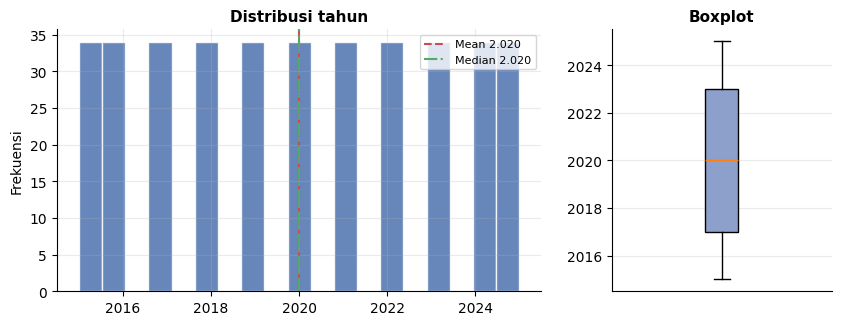

**Interpretasi:** Kolom 'tahun' adalah variabel numerik dengan 374 nilai valid, berkisar dari 2.015 hingga 2.025. Rata-ratanya 2.020 dan mediannya 2.020; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0 menunjukkan distribusi mendekati simetris. Simpangan baku 3,17 dengan koefisien variasi 0,2%, tergolong rendah (data cukup homogen). Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'ihk' (korelasi Pearson |r| = 1,00, tergolong sangat kuat dan berarah positif).

### 🔹 `provinsi_kabupaten`  —  *kategorikal*

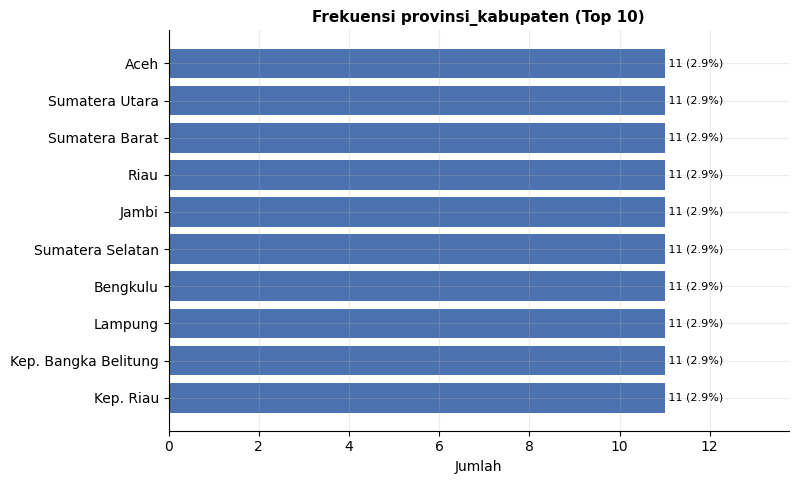

**Interpretasi:** Kolom 'provinsi_kabupaten' adalah variabel kategorikal dengan 34 kategori dari 374 data valid. Kategori terbanyak adalah 'Aceh' dengan porsi 2,9% (relatif tersebar). Tiga kategori teratas ('Aceh', 'Sumatera Utara', 'Sumatera Barat') bersama-sama mencakup 8,8% data. Sebaran antar-kategori cukup merata (entropi ternormalisasi tinggi). Grafik hanya menampilkan 10 kategori teratas. Tidak ada nilai kosong pada kolom ini.

### 🔹 `umr_ump`  —  *numerik*

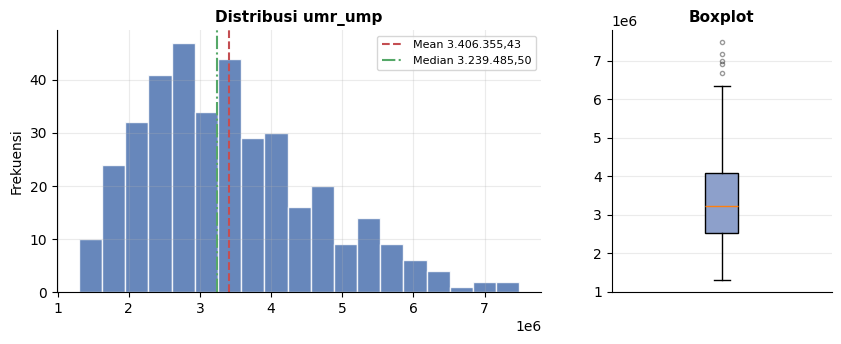

**Interpretasi:** Kolom 'umr_ump' adalah variabel numerik dengan 374 nilai valid, berkisar dari 1.300.000 hingga 7.486.245. Rata-ratanya 3.406.355,43 dan mediannya 3.239.485,50; rata-rata lebih tinggi daripada median, menandakan sebagian kecil nilai besar menarik distribusi ke kanan. Skewness 0,75 menunjukkan distribusi agak miring ke kanan. Simpangan baku 1.206.289,22 dengan koefisien variasi 35,4%, tergolong sedang. Terdeteksi 5 outlier (1,3%) di luar rentang 202.753,12 s.d. 6.420.684,12; jumlahnya relatif kecil, dan hanya ditandai tanpa mengubah data. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'pdrb_per_kapita' (korelasi Pearson |r| = 0,87, tergolong sangat kuat dan berarah positif).

### 🔹 `inflasi`  —  *numerik*

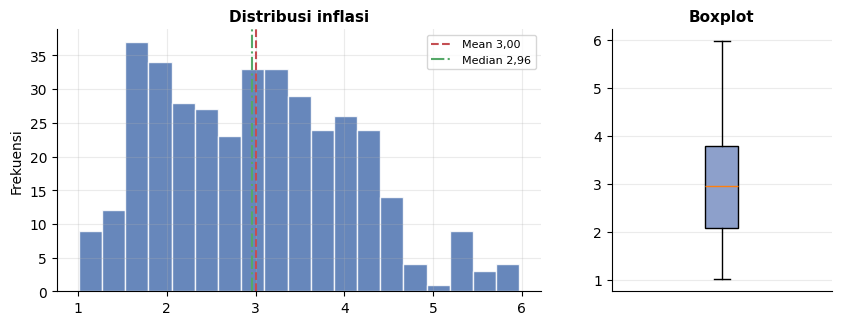

**Interpretasi:** Kolom 'inflasi' adalah variabel numerik dengan 374 nilai valid, berkisar dari 1,01 hingga 5,97. Rata-ratanya 3,00 dan mediannya 2,96; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,38 menunjukkan distribusi mendekati simetris. Simpangan baku 1,08 dengan koefisien variasi 36,1%, tergolong sedang. Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'pertumbuhan_pdrb' (korelasi Pearson |r| = 0,37, tergolong sedang dan berarah positif).

### 🔹 `pdrb_per_kapita`  —  *numerik*

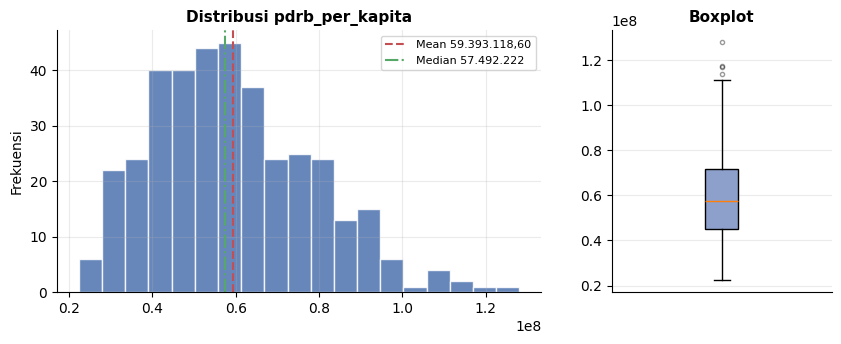

**Interpretasi:** Kolom 'pdrb_per_kapita' adalah variabel numerik dengan 374 nilai valid, berkisar dari 22.363.400 hingga 128.031.180. Rata-ratanya 59.393.118,60 dan mediannya 57.492.222; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,56 menunjukkan distribusi agak miring ke kanan. Simpangan baku 19.328.305,90 dengan koefisien variasi 32,5%, tergolong sedang. Terdeteksi 4 outlier (1,1%) di luar rentang 4.753.383,12 s.d. 112.059.336,12; jumlahnya relatif kecil, dan hanya ditandai tanpa mengubah data. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'umr_ump' (korelasi Pearson |r| = 0,87, tergolong sangat kuat dan berarah positif).

### 🔹 `pertumbuhan_pdrb`  —  *numerik*

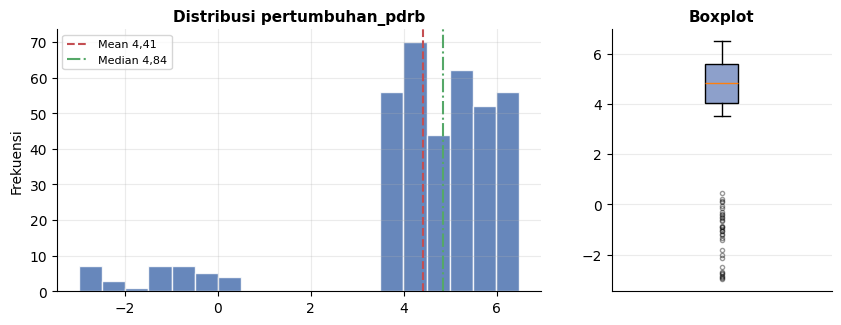

**Interpretasi:** Kolom 'pertumbuhan_pdrb' adalah variabel numerik dengan 374 nilai valid, berkisar dari -2,99 hingga 6,49. Rata-ratanya 4,41 dan mediannya 4,84; rata-rata lebih rendah daripada median, menandakan sebagian kecil nilai kecil menarik distribusi ke kiri. Skewness -2,12 menunjukkan distribusi sangat miring ke kiri. Simpangan baku 2,00 dengan koefisien variasi 45,3%, tergolong sedang. Terdeteksi 34 outlier (9,1%) di luar rentang 1,71 s.d. 7,93; jumlahnya cukup besar dan perlu ditelaah, dan hanya ditandai tanpa mengubah data. Terdapat 30 nilai negatif; pastikan sesuai makna kolom. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'inflasi' (korelasi Pearson |r| = 0,37, tergolong sedang dan berarah positif).

### 🔹 `tingkat_pengangguran_terbuka`  —  *numerik*

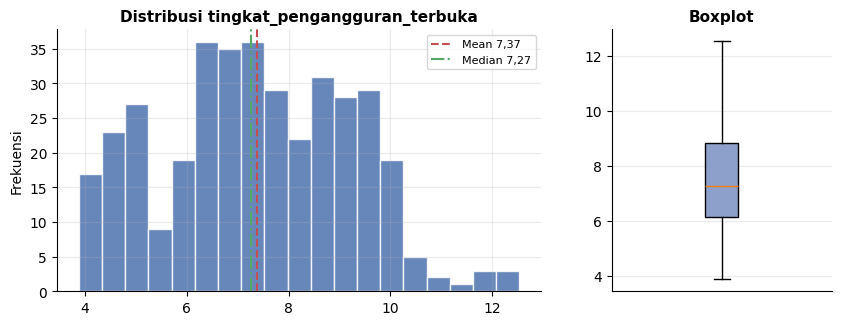

**Interpretasi:** Kolom 'tingkat_pengangguran_terbuka' adalah variabel numerik dengan 374 nilai valid, berkisar dari 3,88 hingga 12,53. Rata-ratanya 7,37 dan mediannya 7,27; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,10 menunjukkan distribusi mendekati simetris. Simpangan baku 1,85 dengan koefisien variasi 25,1%, tergolong sedang. Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'jumlah_industri' (korelasi Pearson |r| = 0,40, tergolong sedang dan berarah negatif).

### 🔹 `ipm`  —  *numerik*

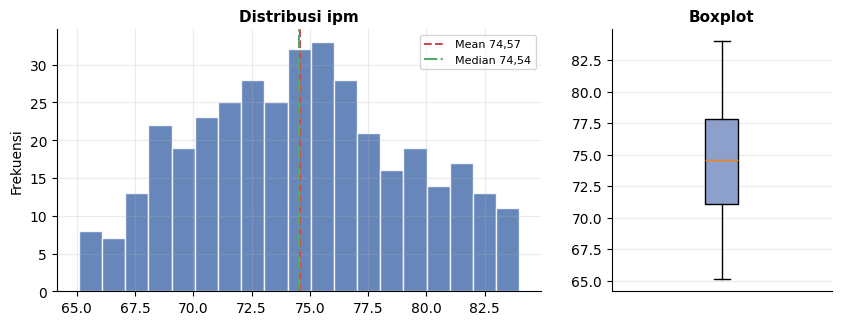

**Interpretasi:** Kolom 'ipm' adalah variabel numerik dengan 374 nilai valid, berkisar dari 65,09 hingga 83,98. Rata-ratanya 74,57 dan mediannya 74,54; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,09 menunjukkan distribusi mendekati simetris. Simpangan baku 4,57 dengan koefisien variasi 6,1%, tergolong rendah (data cukup homogen). Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Tidak ada hubungan yang berarti (kekuatan ≥ 0,3) antara kolom ini dengan kolom lain; hubungan tertinggi hanya dengan 'tahun' (korelasi Pearson |r| = 0,28).

### 🔹 `jumlah_penduduk`  —  *numerik*

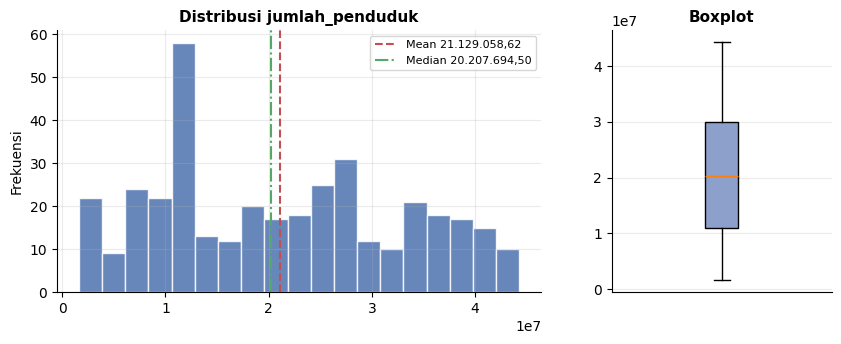

**Interpretasi:** Kolom 'jumlah_penduduk' adalah variabel numerik dengan 374 nilai valid, berkisar dari 1.623.597 hingga 44.268.987. Rata-ratanya 21.129.058,62 dan mediannya 20.207.694,50; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,21 menunjukkan distribusi mendekati simetris. Simpangan baku 11.742.054,77 dengan koefisien variasi 55,6%, tergolong tinggi (data sangat beragam). Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'jumlah_tenaga_kerja' (korelasi Pearson |r| = 1,00, tergolong sangat kuat dan berarah positif).

### 🔹 `persentase_penduduk_miskin`  —  *numerik*

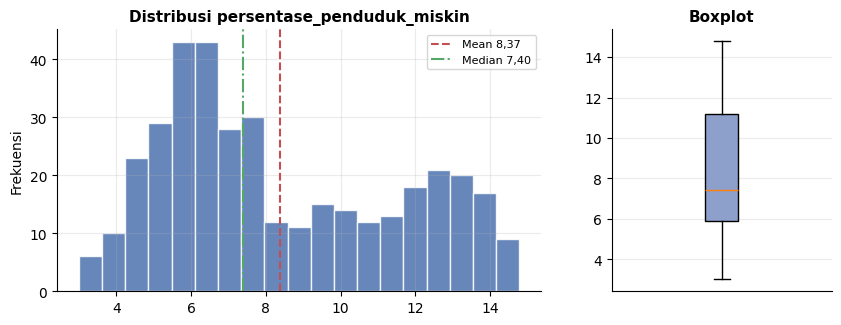

**Interpretasi:** Kolom 'persentase_penduduk_miskin' adalah variabel numerik dengan 374 nilai valid, berkisar dari 3 hingga 14,78. Rata-ratanya 8,37 dan mediannya 7,40; rata-rata lebih tinggi daripada median, menandakan sebagian kecil nilai besar menarik distribusi ke kanan. Skewness 0,43 menunjukkan distribusi mendekati simetris. Simpangan baku 3,14 dengan koefisien variasi 37,5%, tergolong sedang. Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Tidak ada hubungan yang berarti (kekuatan ≥ 0,3) antara kolom ini dengan kolom lain; hubungan tertinggi hanya dengan 'tingkat_pengangguran_terbuka' (korelasi Pearson |r| = 0,24).

### 🔹 `pad`  —  *numerik*

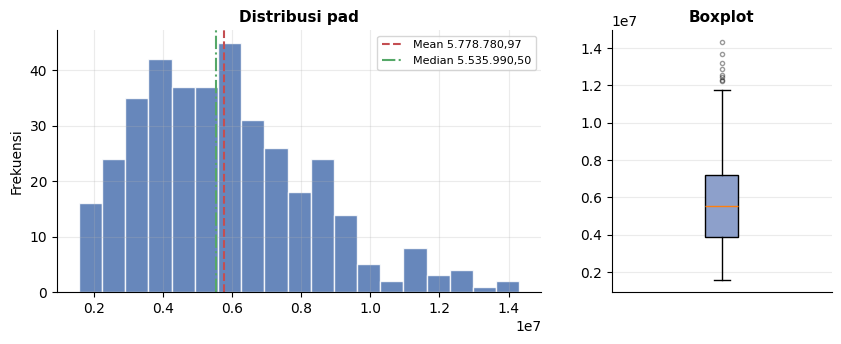

**Interpretasi:** Kolom 'pad' adalah variabel numerik dengan 374 nilai valid, berkisar dari 1.572.795 hingga 14.310.668. Rata-ratanya 5.778.780,97 dan mediannya 5.535.990,50; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,73 menunjukkan distribusi agak miring ke kanan. Simpangan baku 2.497.867,39 dengan koefisien variasi 43,2%, tergolong sedang. Terdeteksi 8 outlier (2,1%) di luar rentang -1.041.331,12 s.d. 12.152.669,88; jumlahnya relatif kecil, dan hanya ditandai tanpa mengubah data. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'pdrb_per_kapita' (korelasi Pearson |r| = 0,73, tergolong sangat kuat dan berarah positif).

### 🔹 `nilai_investasi`  —  *numerik*

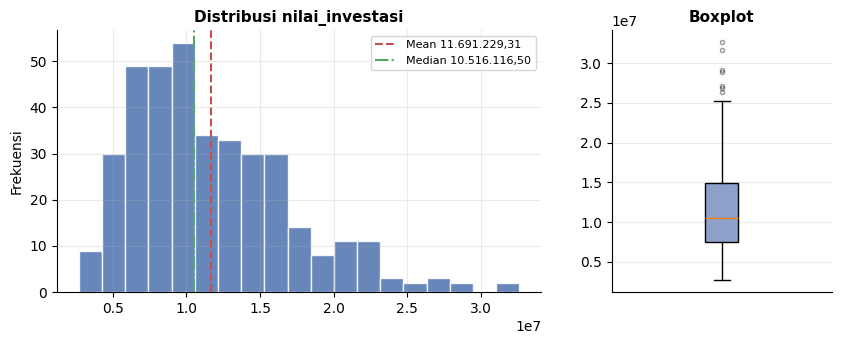

**Interpretasi:** Kolom 'nilai_investasi' adalah variabel numerik dengan 374 nilai valid, berkisar dari 2.696.463 hingga 32.614.878. Rata-ratanya 11.691.229,31 dan mediannya 10.516.116,50; rata-rata lebih tinggi daripada median, menandakan sebagian kecil nilai besar menarik distribusi ke kanan. Skewness 0,97 menunjukkan distribusi agak miring ke kanan. Simpangan baku 5.397.946,36 dengan koefisien variasi 46,2%, tergolong sedang. Terdeteksi 7 outlier (1,9%) di luar rentang -3.523.371,12 s.d. 25.928.455,88; jumlahnya relatif kecil, dan hanya ditandai tanpa mengubah data. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'pdrb_per_kapita' (korelasi Pearson |r| = 0,75, tergolong sangat kuat dan berarah positif).

### 🔹 `ihk`  —  *numerik*

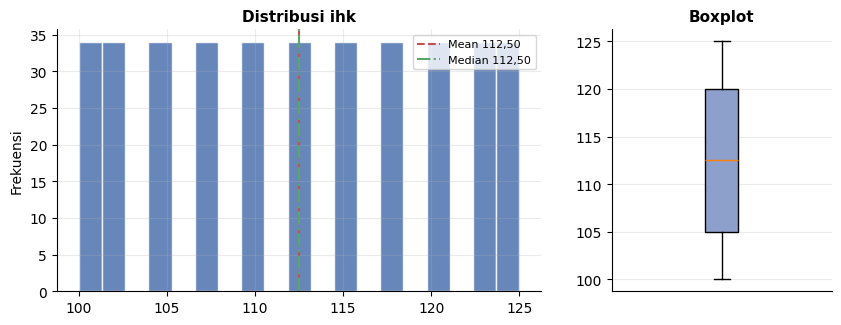

**Interpretasi:** Kolom 'ihk' adalah variabel numerik dengan 374 nilai valid, berkisar dari 100 hingga 125. Rata-ratanya 112,50 dan mediannya 112,50; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0 menunjukkan distribusi mendekati simetris. Simpangan baku 7,92 dengan koefisien variasi 7,0%, tergolong rendah (data cukup homogen). Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'tahun' (korelasi Pearson |r| = 1,00, tergolong sangat kuat dan berarah positif).

### 🔹 `jumlah_industri`  —  *numerik*

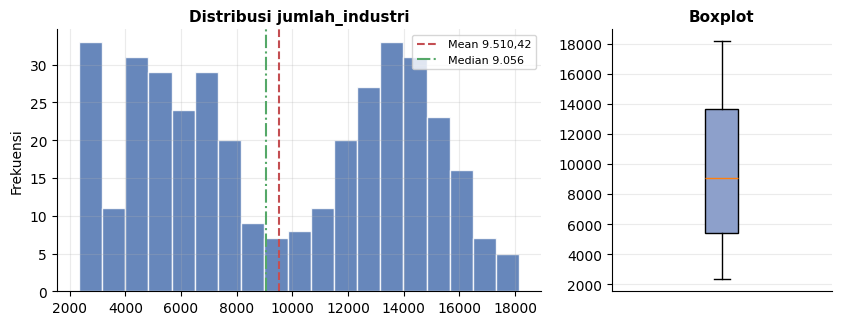

**Interpretasi:** Kolom 'jumlah_industri' adalah variabel numerik dengan 374 nilai valid, berkisar dari 2.330 hingga 18.154. Rata-ratanya 9.510,42 dan mediannya 9.056; rata-rata lebih tinggi daripada median, menandakan sebagian kecil nilai besar menarik distribusi ke kanan. Skewness 0,03 menunjukkan distribusi mendekati simetris. Simpangan baku 4.522,59 dengan koefisien variasi 47,6%, tergolong sedang. Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'tingkat_pengangguran_terbuka' (korelasi Pearson |r| = 0,40, tergolong sedang dan berarah negatif).

### 🔹 `jumlah_tenaga_kerja`  —  *numerik*

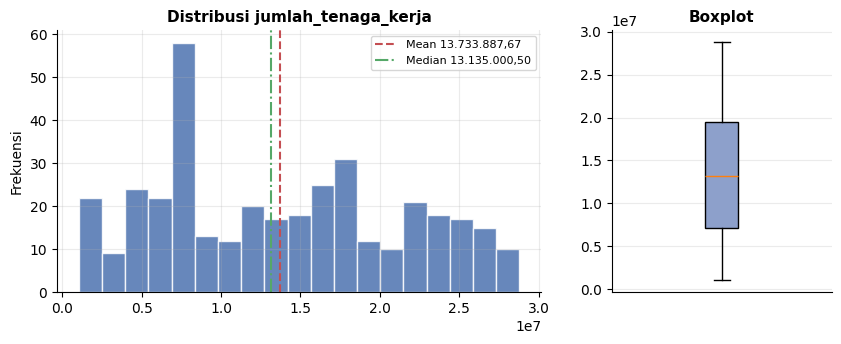

**Interpretasi:** Kolom 'jumlah_tenaga_kerja' adalah variabel numerik dengan 374 nilai valid, berkisar dari 1.055.338 hingga 28.774.841. Rata-ratanya 13.733.887,67 dan mediannya 13.135.000,50; keduanya berdekatan sehingga sebaran cenderung simetris. Skewness 0,21 menunjukkan distribusi mendekati simetris. Simpangan baku 7.632.335,59 dengan koefisien variasi 55,6%, tergolong tinggi (data sangat beragam). Tidak ditemukan outlier berdasarkan aturan IQR. Tidak ada nilai kosong pada kolom ini. Hubungan terkuat adalah dengan kolom 'jumlah_penduduk' (korelasi Pearson |r| = 1,00, tergolong sangat kuat dan berarah positif).

In [ ]:
# ── Fungsi plot univariat ──────────────────────────────────────────────────
def plot_numeric(c):
    x = df[c].dropna().astype(float); p = profiles[c]
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
    ax[0].hist(x, bins=min(40, max(10, int(np.sqrt(len(x))))), color="#4C72B0", alpha=.85, edgecolor="white")
    ax[0].axvline(p["mean"], color="#C44E52", ls="--", label=f"Mean {fmt(p['mean'])}")
    ax[0].axvline(p["median"], color="#55A868", ls="-.", label=f"Median {fmt(p['median'])}")
    ax[0].set_title(f"Distribusi {c}"); ax[0].set_ylabel("Frekuensi"); ax[0].legend(fontsize=8)
    ax[1].boxplot(x, patch_artist=True, boxprops=dict(facecolor="#8DA0CB"), flierprops=dict(marker="o", markersize=3, alpha=.4))
    ax[1].set_title("Boxplot"); ax[1].set_xticks([])
    return save_fig(fig, f"uni_{c}")

def plot_cat(c):
    p = profiles[c]; vc = p["vc"].head(CONFIG["TOP_N"])
    if pd.api.types.is_numeric_dtype(df[c]): vc = vc.sort_index()
    total = p["vc"].sum()
    fig, ax = plt.subplots(figsize=(8, max(2.4, .4 * len(vc) + 1.2)))
    labels = [str(i)[:32] for i in vc.index][::-1]
    ax.barh(labels, vc.values[::-1], color="#4C72B0")
    for i, v in enumerate(vc.values[::-1]): ax.text(v, i, f" {v:,} ({v / total * 100:.1f}%)", va="center", fontsize=8)
    ax.set_xlim(0, vc.max() * 1.25); ax.set_title(f"Frekuensi {c}" + (f" (Top {CONFIG['TOP_N']})" if p["n_unique"] > CONFIG["TOP_N"] else ""))
    ax.set_xlabel("Jumlah")
    return save_fig(fig, f"uni_{c}")

def plot_datetime(c):
    p = profiles[c]; per = p["period_counts"]; x = per.index.to_timestamp()
    fig, ax = plt.subplots(figsize=(10, 3.2))
    if len(per) <= 60: ax.bar(x, per.values, width=(20 if p["freq"] == "M" else 0.8 if p["freq"] == "D" else 300), color="#4C72B0")
    else: ax.plot(x, per.values, color="#4C72B0"); ax.fill_between(x, per.values, alpha=.2)
    ax.set_title(f"Jumlah catatan per periode ({p['freq_label']}) — {c}"); ax.set_ylabel("Jumlah catatan")
    return save_fig(fig, f"uni_{c}")

def plot_text(c):
    p = profiles[c]; st = df[c].dropna().astype(str)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
    ax[0].hist(st.str.len(), bins=30, color="#8172B2", edgecolor="white"); ax[0].set_title("Panjang teks (karakter)")
    if p["top_words"]:
        w = p["top_words"][:10][::-1]; ax[1].barh([a for a, _ in w], [b for _, b in w], color="#4C72B0"); ax[1].set_title("Kata paling sering")
    return save_fig(fig, f"uni_{c}")

PLOTTERS = {"numeric": plot_numeric, "categorical": plot_cat, "boolean": plot_cat, "datetime": plot_datetime, "text": plot_text}

# ── Jalankan untuk semua kolom ─────────────────────────────────────────────
report_cols = []
for c in df.columns:
    t = col_types[c]
    display(Markdown(f"### 🔹 `{c}`  —  *{TYPE_LABEL[t]}*"))
    fig_path = None
    if t in PLOTTERS:
        try: fig_path = PLOTTERS[t](c)
        except Exception as e: print(f"  (grafik '{c}' dilewati: {e})")
    text = INTERPRET[t](c)
    display(Markdown(f"**Interpretasi:** {text}"))
    report_cols.append(dict(name=c, type=t, stats=stats_for(c), fig=fig_path, text=text))

## 6️⃣ Hubungan Antar Variabel

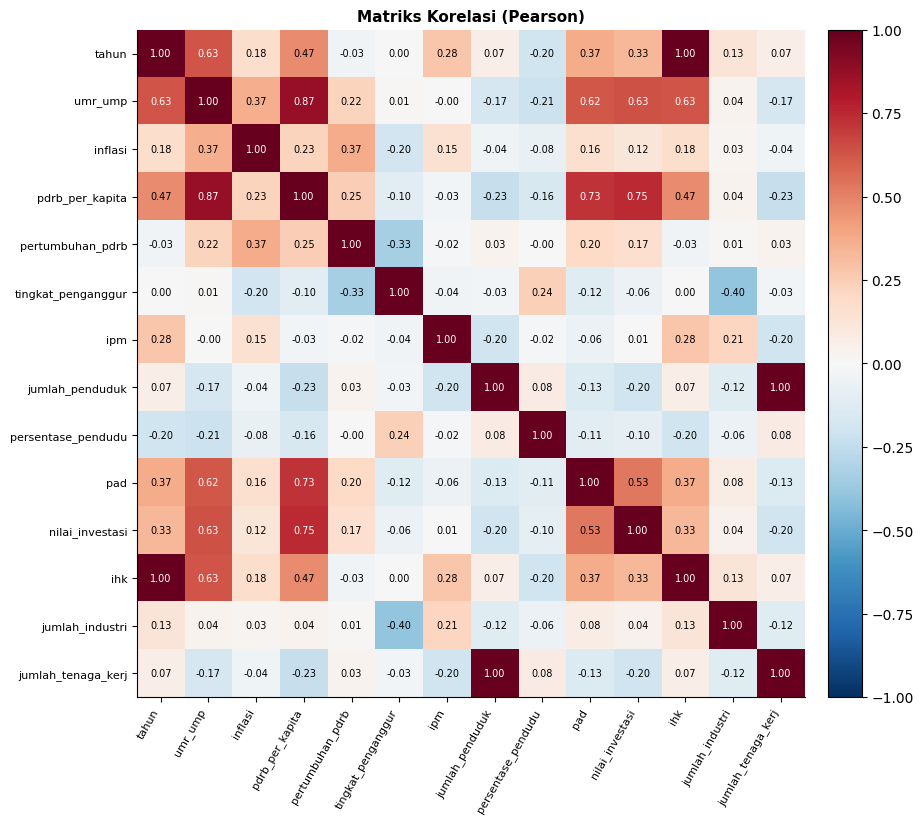

**Pasangan variabel dengan hubungan terkuat:**

,Variabel A,Variabel B,Ukuran,Kekuatan,Kategori
0,tahun,ihk,korelasi Pearson |r|,1.000,sangat kuat (+)
1,jumlah_penduduk,jumlah_tenaga_kerja,korelasi Pearson |r|,1.000,sangat kuat (+)
2,umr_ump,pdrb_per_kapita,korelasi Pearson |r|,0.868,sangat kuat (+)
3,pdrb_per_kapita,nilai_investasi,korelasi Pearson |r|,0.747,sangat kuat (+)
4,pdrb_per_kapita,pad,korelasi Pearson |r|,0.726,sangat kuat (+)
5,umr_ump,nilai_investasi,korelasi Pearson |r|,0.633,kuat (+)
6,umr_ump,ihk,korelasi Pearson |r|,0.628,kuat (+)
7,tahun,umr_ump,korelasi Pearson |r|,0.628,kuat (+)


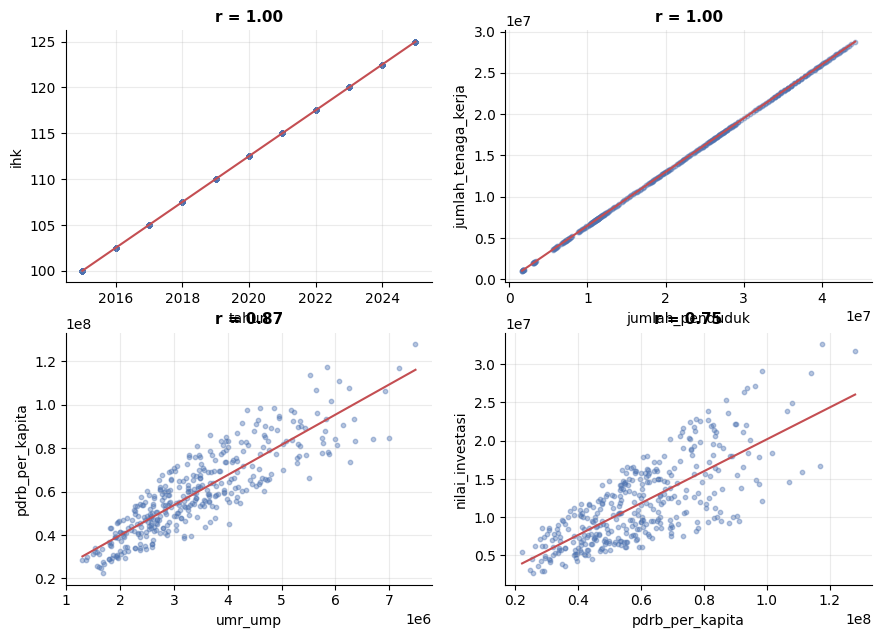

**Interpretasi:** Hubungan terkuat di seluruh dataset ada antara 'tahun' dan 'ihk' (korelasi Pearson |r| = 1,00, sangat kuat, searah). Terdapat 10 pasangan variabel dengan hubungan kuat (≥ 0,5). Peringatan multikolinearitas: 'tahun'–'ihk' (1,00); 'jumlah_penduduk'–'jumlah_tenaga_kerja' (1,00). Pasangan ini hampir redundan; pertimbangkan memakai salah satunya saja pada pemodelan. Catatan: asosiasi bukan bukti hubungan sebab-akibat.

In [ ]:
def heatmap(M, title, fname, vmin, vmax, cmap, annot_limit=14):
    n = len(M); size = max(5, min(12, .55 * n + 2.5))
    fig, ax = plt.subplots(figsize=(size, size * .85))
    im = ax.imshow(M.values, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(n)); ax.set_xticklabels([str(c)[:18] for c in M.columns], rotation=60, ha="right", fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels([str(c)[:18] for c in M.index], fontsize=8); ax.grid(False)
    if n <= annot_limit:
        for i in range(n):
            for j in range(n):
                v = M.values[i, j]
                if pd.notna(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if abs(v - (vmin + vmax) / 2) > (vmax - vmin) * .3 else "black")
    ax.set_title(title); fig.colorbar(im, fraction=.046, pad=.03)
    return save_fig(fig, fname)

biv = dict(corr_fig=None, assoc_fig=None, scatter_figs=[], box_figs=[], cat_figs=[], texts=[])

# 6a. Heatmap korelasi numerik
num_corr_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and col_types[c] in ("numeric", "categorical", "boolean")
                 and not (col_types[c] != "numeric" and df[c].nunique() < 3)][:CONFIG["MAX_ASSOC_COLS"]]
num_only = [c for c in num_corr_cols if col_types[c] == "numeric"]
if len(num_only) >= 2:
    C = df[num_only].corr(method=CONFIG["CORR_METHOD"])
    biv["corr_fig"] = heatmap(C, f"Matriks Korelasi ({CONFIG['CORR_METHOD'].capitalize()})", "bi_korelasi", -1, 1, "RdBu_r")
else:
    print("Kurang dari 2 kolom numerik — heatmap korelasi dilewati.")

# 6b. Heatmap asosiasi lintas tipe (numerik + kategorikal)
has_cat = any(assoc_kind(c) == "cat" for c in assoc_cols)
if len(assoc_cols) >= 3 and has_cat:
    A = pd.DataFrame(np.nan, index=assoc_cols, columns=assoc_cols)
    for c in assoc_cols: A.loc[c, c] = 1.0
    for q in pairs: A.loc[q["a"], q["b"]] = A.loc[q["b"], q["a"]] = q["strength"]
    biv["assoc_fig"] = heatmap(A, "Matriks Asosiasi Lintas Tipe (0 = tidak ada, 1 = sempurna)", "bi_asosiasi", 0, 1, "YlOrRd")
    display(Markdown("*Angka: |korelasi| untuk numerik–numerik, rasio korelasi η untuk kategorikal–numerik, Cramér's V untuk kategorikal–kategorikal.*"))

# 6c. Pasangan terkuat
top_pairs = pairs[:8]
if top_pairs:
    display(Markdown("**Pasangan variabel dengan hubungan terkuat:**"))
    display(pd.DataFrame([{"Variabel A": q["a"], "Variabel B": q["b"], "Ukuran": q["label"], "Kekuatan": round(q["strength"], 3),
                           "Kategori": strength_label(q["strength"]) + (" (+)" if q["sign"] > 0 else " (−)" if q["sign"] < 0 else "")} for q in top_pairs]))

# 6d. Scatter plot pasangan numerik terkuat
nn_pairs = [q for q in pairs if q["method"] in ("pearson", "spearman")][:4]
if nn_pairs:
    k = len(nn_pairs); cols = 2 if k > 1 else 1; rows = (k + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.6 * rows), squeeze=False)
    for ax in axes.ravel(): ax.set_visible(False)
    for ax, q in zip(axes.ravel(), nn_pairs):
        ax.set_visible(True); d = df[[q["a"], q["b"]]].dropna()
        d = d.sample(min(len(d), 4000), random_state=0)
        ax.scatter(d[q["a"]], d[q["b"]], s=10, alpha=.4, color="#4C72B0")
        if len(d) > 2:
            m, b0 = np.polyfit(d[q["a"]].astype(float), d[q["b"]].astype(float), 1)
            xs = np.linspace(d[q["a"]].min(), d[q["a"]].max(), 50); ax.plot(xs, m * xs + b0, color="#C44E52", lw=1.5)
        ax.set_xlabel(q["a"]); ax.set_ylabel(q["b"]); ax.set_title(f"r = {q['sign']:.2f}")
    biv["scatter_figs"].append(save_fig(fig, "bi_scatter"))

# 6e. Boxplot numerik berdasarkan kategori (pasangan η terkuat)
eta_pairs = [q for q in pairs if q["method"] == "eta" and q["strength"] >= 0.2][:3]
if eta_pairs:
    fig, axes = plt.subplots(1, len(eta_pairs), figsize=(5.4 * len(eta_pairs), 3.8), squeeze=False)
    for ax, q in zip(axes.ravel(), eta_pairs):
        cat, num = (q["a"], q["b"]) if assoc_kind(q["a"]) == "cat" else (q["b"], q["a"])
        top = df[cat].value_counts().head(8).index
        groups = [df.loc[df[cat] == g, num].dropna().values for g in top]
        ax.boxplot(groups, labels=[str(g)[:12] for g in top], patch_artist=True, boxprops=dict(facecolor="#8DA0CB"),
                   flierprops=dict(marker="o", markersize=2, alpha=.3))
        ax.set_title(f"{num} per {cat}\n(η = {q['strength']:.2f})", fontsize=10); ax.tick_params(axis="x", rotation=45)
    biv["box_figs"].append(save_fig(fig, "bi_boxplot"))

# 6f. Kategorikal vs kategorikal (100% stacked)
cv_pairs = [q for q in pairs if q["method"] == "cramer" and q["strength"] >= 0.2][:2]
if cv_pairs:
    fig, axes = plt.subplots(1, len(cv_pairs), figsize=(6 * len(cv_pairs), 3.8), squeeze=False)
    for ax, q in zip(axes.ravel(), cv_pairs):
        ta = df[q["a"]].value_counts().head(8).index; tb = df[q["b"]].value_counts().head(6).index
        d = df[df[q["a"]].isin(ta) & df[q["b"]].isin(tb)]
        ct = pd.crosstab(d[q["a"]], d[q["b"]], normalize="index") * 100
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=.8, legend=True)
        ax.set_title(f"{q['b']} per {q['a']} (V = {q['strength']:.2f})", fontsize=10); ax.set_ylabel("%"); ax.set_xlabel("")
        ax.legend(fontsize=7, title=None, bbox_to_anchor=(1, 1)); ax.tick_params(axis="x", rotation=45)
    biv["cat_figs"].append(save_fig(fig, "bi_kategori"))

# 6g. Narasi
tx = []
if pairs:
    q = pairs[0]
    tx.append(f"Hubungan terkuat di seluruh dataset ada antara '{q['a']}' dan '{q['b']}' ({q['label']} = {fmt(q['strength'])}, {strength_label(q['strength'])}"
              + (", searah" if q['sign'] > 0 else ", berlawanan arah" if q['sign'] < 0 else "") + ").")
    strong = [q for q in pairs if q["strength"] >= 0.5]
    tx.append(f"Terdapat {len(strong)} pasangan variabel dengan hubungan kuat (≥ 0,5)." if strong else "Tidak ada pasangan variabel dengan hubungan kuat (≥ 0,5); variabel relatif independen satu sama lain.")
    coll = [q for q in pairs if q["method"] in ("pearson", "spearman") and q["strength"] >= 0.9]
    if coll: tx.append("Peringatan multikolinearitas: " + "; ".join(f"'{q['a']}'–'{q['b']}' ({fmt(q['strength'])})" for q in coll[:5]) + ". Pasangan ini hampir redundan; pertimbangkan memakai salah satunya saja pada pemodelan.")
    tx.append("Catatan: asosiasi bukan bukti hubungan sebab-akibat.")
else:
    tx.append("Tidak cukup variabel (minimal dua kolom numerik/kategorikal) untuk analisis hubungan antar variabel.")
biv["texts"] = tx
display(Markdown("**Interpretasi:** " + " ".join(tx)))

## 7️⃣ Analisis Deret Waktu (jika ada kolom tanggal)

In [ ]:
ts = dict(fig=None, text=None, col=None)
dt_cols = [c for c in df.columns if col_types[c] == "datetime"]
dcol = DATE_COL_CFG if (DATE_COL_CFG in dt_cols) else (dt_cols[0] if dt_cols else None)
nums_ts = [c for c in df.columns if col_types[c] == "numeric"][:3]
if dcol and nums_ts:
    p = profiles[dcol]; freq = p["freq"]; tmp = df.dropna(subset=[dcol])
    g = tmp.groupby(tmp[dcol].dt.to_period(freq))[nums_ts].mean()
    g.index = g.index.to_timestamp()
    fig, axes = plt.subplots(len(nums_ts), 1, figsize=(10, 2.6 * len(nums_ts)), sharex=True, squeeze=False)
    sents = [f"Rata-rata variabel numerik diagregasi secara {p['freq_label']} berdasarkan kolom '{dcol}'."]
    for ax, c in zip(axes.ravel(), nums_ts):
        ax.plot(g.index, g[c], marker="o", ms=3, color="#4C72B0"); ax.set_ylabel(c[:16]); ax.set_title(f"Rata-rata {c} per periode", fontsize=10)
        sents.append(f"'{c}' {trend_label(g[c])}.")
    ts.update(fig=save_fig(fig, "ts_numerik"), col=dcol, text=" ".join(sents))
    display(Markdown("**Interpretasi:** " + ts["text"]))
else:
    print("Tidak ada kombinasi kolom tanggal + numerik — bagian ini dilewati.")

Tidak ada kombinasi kolom tanggal + numerik — bagian ini dilewati.


## 8️⃣ Analisis Target (opsional — isi `CONFIG['TARGET']`)

In [ ]:
tgt = dict(fig=None, text=None)
if TARGET and assoc_kind(TARGET):
    rows = []
    for c in df.columns:
        if c == TARGET or not assoc_kind(c): continue
        v, m, sign = assoc_pair(TARGET, c)
        if pd.notna(v): rows.append((c, v, m, sign))
    rows.sort(key=lambda z: -z[1])
    if rows:
        top = rows[:15][::-1]
        fig, ax = plt.subplots(figsize=(8, max(2.4, .38 * len(top) + 1.2)))
        ax.barh([r[0][:28] for r in top], [r[1] for r in top], color=["#C44E52" if r[3] < 0 else "#4C72B0" for r in top])
        for i, r in enumerate(top): ax.text(r[1], i, f" {r[1]:.2f}", va="center", fontsize=8)
        ax.set_xlim(0, max(r[1] for r in top) * 1.15); ax.set_xlabel("Kekuatan hubungan dengan target (0–1)")
        ax.set_title(f"Faktor yang Berasosiasi dengan '{TARGET}'")
        tgt["fig"] = save_fig(fig, "target_asosiasi")
        best = rows[:3]
        tgt["text"] = (f"Target '{TARGET}' bertipe {TYPE_LABEL[col_types[TARGET]]}. Variabel dengan asosiasi tertinggi: "
                       + "; ".join(f"'{r[0]}' ({METHOD_LABEL[r[2]]} = {fmt(r[1])}, {strength_label(r[1])}" + (", searah" if r[3] > 0 else ", berlawanan" if r[3] < 0 else "") + ")" for r in best)
                       + ". Variabel-variabel ini adalah kandidat fitur utama untuk pemodelan atau analisis lanjutan, bukan bukti sebab-akibat.")
        display(Markdown("**Interpretasi:** " + tgt["text"]))
else:
    print("TARGET tidak diatur / tidak cocok — bagian ini dilewati." if not TARGET else f"Tipe target '{TARGET}' tidak didukung untuk analisis asosiasi.")

TARGET tidak diatur / tidak cocok — bagian ini dilewati.


## 9️⃣ Ringkasan Eksekutif, Kesimpulan & Rekomendasi (otomatis)

In [ ]:
findings, recs = [], []
tc = Counter(col_types.values())
tc_txt = ", ".join(f"{v} {TYPE_LABEL[k]}" for k, v in tc.most_common())
findings.append(f"Dataset '{DATASET_NAME}' awalnya terdiri atas {fmt(orig_shape[0])} baris dan {fmt(orig_shape[1])} kolom; setelah cleaning menjadi {fmt(df.shape[0])} baris dan {fmt(df.shape[1])} kolom ({tc_txt}).")

tot_cells = orig_shape[0] * orig_shape[1]; miss_cells = int(df_raw.isna().sum().sum())
q_txt = f"Kualitas data: {fmt(miss_cells / max(tot_cells, 1) * 100, 2)}% sel kosong pada data mentah dan {fmt(dup_n)} baris duplikat."
worst = missing_before.sort_values(ascending=False)
if worst.iloc[0] > 0: q_txt += f" Kolom dengan missing terbanyak: '{worst.index[0]}' ({fmt(worst.iloc[0] / max(n_rows_pre, 1) * 100, 1)}%)."
findings.append(q_txt)

skewed = [c for c in df.columns if col_types[c] == "numeric" and abs(profiles[c].get("skew", 0) or 0) > 1]
if skewed:
    findings.append(f"{len(skewed)} kolom numerik sangat miring (|skewness| > 1): {', '.join(skewed[:6])}{'…' if len(skewed) > 6 else ''}.")
    recs.append("Pertimbangkan transformasi (log, akar kuadrat, Box-Cox) pada kolom numerik yang sangat miring bila dipakai untuk model yang sensitif terhadap distribusi.")
heavy = sorted([(c, v["out_pct"]) for c, v in outlier_info.items() if v["out_pct"] > 5], key=lambda z: -z[1])
if heavy:
    findings.append("Kolom dengan proporsi outlier tinggi (>5%): " + ", ".join(f"{c} ({fmt(p_, 1)}%)" for c, p_ in heavy[:5]) + ".")
    recs.append("Telusuri outlier pada kolom tersebut: apakah kesalahan input, nilai ekstrem yang sah, atau segmen tersendiri; putuskan perlakuan (biarkan, cap, atau hapus) berdasarkan konteks bisnis.")
dom = [c for c in df.columns if col_types[c] in ("categorical", "boolean") and profiles[c]["top_share"] >= 80]
if dom:
    findings.append(f"Kolom kategorikal yang sangat didominasi satu kategori (≥80%): {', '.join(dom[:6])}.")
    recs.append("Kolom yang sangat didominasi satu kategori memiliki daya pembeda rendah; evaluasi apakah masih relevan.")
junk = [c for c in df.columns if col_types[c] == "constant"]
if junk:
    findings.append(f"Kolom konstan (tidak informatif): {', '.join(junk)}."); recs.append("Buang kolom konstan karena tidak membawa informasi.")
ids = [c for c in df.columns if col_types[c] == "id"]
if ids:
    findings.append(f"Kolom identifier terdeteksi: {', '.join(ids)}."); recs.append("Kolom identifier jangan dipakai sebagai fitur model; gunakan hanya sebagai kunci baris.")
if pairs: findings.append(biv["texts"][0])
if any(q["method"] in ("pearson", "spearman") and q["strength"] >= .9 for q in pairs):
    recs.append("Ada pasangan variabel numerik berkorelasi sangat tinggi (≥0,9); kurangi redundansi (mis. buang salah satu atau gunakan PCA) untuk menghindari multikolinearitas.")
if dcol: findings.append(f"Kolom waktu '{dcol}' mencakup {profiles[dcol]['min']:%d %b %Y} – {profiles[dcol]['max']:%d %b %Y}; jumlah catatan {profiles[dcol]['trend']}.")
if tgt["text"]: findings.append(tgt["text"])
if TARGET and col_types.get(TARGET) in ("categorical", "boolean") and profiles[TARGET]["top_share"] >= 70:
    recs.append(f"Kelas target '{TARGET}' tidak seimbang; gunakan stratified split, class weight, atau resampling (SMOTE) saat pemodelan.")
if impute_methods and CONFIG["MISSING_STRATEGY"] == "impute":
    recs.append("Imputasi sederhana (median/modus) dapat mengecilkan variasi data; untuk analisis lanjutan pertimbangkan imputasi berbasis model (KNN/MICE) bila persentase missing besar.")
if not any("target" in r.lower() for r in recs) and not TARGET:
    recs.append("Tentukan variabel target (CONFIG['TARGET']) untuk mendapatkan analisis faktor yang berasosiasi dan rekomendasi fitur.")
recs.append("Validasi temuan bersama pemilik data/pakar domain sebelum mengambil keputusan; asosiasi statistik tidak membuktikan sebab-akibat.")

display(Markdown("### Temuan Utama\n" + "\n".join(f"- {f}" for f in findings)))
display(Markdown("### Rekomendasi\n" + "\n".join(f"- {r}" for r in recs)))

### Temuan Utama
- Dataset 'dataset_ump_lengkap_2015_2025' awalnya terdiri atas 374 baris dan 15 kolom; setelah cleaning menjadi 374 baris dan 15 kolom (14 numerik, 1 kategorikal).
- Kualitas data: 0% sel kosong pada data mentah dan 0 baris duplikat.
- 1 kolom numerik sangat miring (|skewness| > 1): pertumbuhan_pdrb.
- Kolom dengan proporsi outlier tinggi (>5%): pertumbuhan_pdrb (9,1%).
- Hubungan terkuat di seluruh dataset ada antara 'tahun' dan 'ihk' (korelasi Pearson |r| = 1,00, sangat kuat, searah).

### Rekomendasi
- Pertimbangkan transformasi (log, akar kuadrat, Box-Cox) pada kolom numerik yang sangat miring bila dipakai untuk model yang sensitif terhadap distribusi.
- Telusuri outlier pada kolom tersebut: apakah kesalahan input, nilai ekstrem yang sah, atau segmen tersendiri; putuskan perlakuan (biarkan, cap, atau hapus) berdasarkan konteks bisnis.
- Ada pasangan variabel numerik berkorelasi sangat tinggi (≥0,9); kurangi redundansi (mis. buang salah satu atau gunakan PCA) untuk menghindari multikolinearitas.
- Tentukan variabel target (CONFIG['TARGET']) untuk mendapatkan analisis faktor yang berasosiasi dan rekomendasi fitur.
- Validasi temuan bersama pemilik data/pakar domain sebelum mengambil keputusan; asosiasi statistik tidak membuktikan sebab-akibat.

## 🔟 Membuat Laporan Word (.docx)
Laporan memuat: ringkasan eksekutif → gambaran dataset → log cleaning → kualitas data → **analisis & interpretasi setiap kolom (tabel statistik + grafik + narasi)** → hubungan antar variabel → deret waktu → analisis target → kesimpulan & rekomendasi → lampiran kamus data.

In [ ]:
from docx import Document
from docx.shared import Pt, Cm, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

NAVY = RGBColor(0x1F, 0x4E, 0x79)

def shade(cell, hex_fill):
    tcPr = cell._tc.get_or_add_tcPr(); shd = OxmlElement("w:shd")
    shd.set(qn("w:val"), "clear"); shd.set(qn("w:color"), "auto"); shd.set(qn("w:fill"), hex_fill); tcPr.append(shd)

def set_cell(cell, text, bold=False, size=9, color=None, align=None):
    cell.text = ""; para = cell.paragraphs[0]; run = para.add_run(str(text)); run.bold = bold; run.font.size = Pt(size)
    if color: run.font.color.rgb = color
    if align: para.alignment = align
    para.paragraph_format.space_after = Pt(0)

def add_table(doc, header, rows, widths_cm, size=9):
    t = doc.add_table(rows=1, cols=len(header)); t.style = "Table Grid"; t.alignment = WD_TABLE_ALIGNMENT.CENTER; t.autofit = False
    for i, h in enumerate(header):
        set_cell(t.rows[0].cells[i], h, bold=True, size=size, color=RGBColor(255, 255, 255)); shade(t.rows[0].cells[i], "1F4E79")
    for r in rows:
        cells = t.add_row().cells
        for i, v in enumerate(r): set_cell(cells[i], v, size=size)
    for row in t.rows:
        for i, w in enumerate(widths_cm): row.cells[i].width = Cm(w)
    doc.add_paragraph().paragraph_format.space_after = Pt(2)
    return t

def add_kv_grid(doc, items, size=9):
    # tabel 4 kolom: label | nilai | label | nilai
    pairs_ = [items[i:i + 2] for i in range(0, len(items), 2)]
    t = doc.add_table(rows=0, cols=4); t.style = "Table Grid"; t.alignment = WD_TABLE_ALIGNMENT.CENTER; t.autofit = False
    for pr in pairs_:
        cells = t.add_row().cells
        for k in range(2):
            lab, val = pr[k] if k < len(pr) else ("", "")
            set_cell(cells[2 * k], lab, bold=True, size=size); shade(cells[2 * k], "EAF1F8"); set_cell(cells[2 * k + 1], val, size=size)
    for row in t.rows:
        for i, w in enumerate([3.4, 4.9, 3.4, 4.9]): row.cells[i].width = Cm(w)
    doc.add_paragraph().paragraph_format.space_after = Pt(2)

def add_picture(doc, path, width_cm=16):
    if path and os.path.exists(path):
        doc.add_picture(path, width=Cm(width_cm)); doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER

def add_para(doc, text, bold_prefix=None, size=10.5, justify=True):
    p = doc.add_paragraph()
    if bold_prefix: r = p.add_run(bold_prefix); r.bold = True; r.font.size = Pt(size)
    r = p.add_run(text); r.font.size = Pt(size)
    if justify: p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    p.paragraph_format.space_after = Pt(6)
    return p

def add_bullets(doc, items):
    for it in items:
        p = doc.add_paragraph(style="List Bullet"); r = p.add_run(it); r.font.size = Pt(10.5); p.paragraph_format.space_after = Pt(2)

def add_page_number(section):
    p = section.footer.paragraphs[0]; p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run("Halaman "); run.font.size = Pt(9)
    run = p.add_run(); run.font.size = Pt(9)
    for tag in ("begin", "instr", "end"):
        if tag == "instr": el = OxmlElement("w:instrText"); el.set(qn("xml:space"), "preserve"); el.text = " PAGE "
        else: el = OxmlElement("w:fldChar"); el.set(qn("w:fldCharType"), tag)
        run._r.append(el)

doc = Document()
sec = doc.sections[0]
sec.page_width, sec.page_height = Cm(21), Cm(29.7)
sec.left_margin = sec.right_margin = Cm(2.2); sec.top_margin = sec.bottom_margin = Cm(2.0)
st = doc.styles["Normal"]; st.font.name = "Calibri"; st.font.size = Pt(10.5)
st.element.rPr.rFonts.set(qn("w:eastAsia"), "Calibri")
for lvl, sz in ((1, 16), (2, 12.5), (3, 11)):
    h = doc.styles[f"Heading {lvl}"]; h.font.name = "Calibri"; h.font.size = Pt(sz); h.font.color.rgb = NAVY; h.font.bold = True
    h.element.rPr.rFonts.set(qn("w:eastAsia"), "Calibri"); h.element.rPr.rFonts.set(qn("w:ascii"), "Calibri"); h.element.rPr.rFonts.set(qn("w:hAnsi"), "Calibri")
add_page_number(sec)

# ── Halaman judul ──────────────────────────────────────────────────────────
for _ in range(7): doc.add_paragraph()
p = doc.add_paragraph(); p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run(CONFIG["REPORT_TITLE"]); r.bold = True; r.font.size = Pt(28); r.font.color.rgb = NAVY
p = doc.add_paragraph(); p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run(f"Dataset: {DATASET_NAME}"); r.font.size = Pt(16)
p = doc.add_paragraph(); p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run(f"Sumber file: {FILE_NAME}"); r.font.size = Pt(11); r.font.color.rgb = RGBColor(0x59, 0x59, 0x59)
p = doc.add_paragraph(); p.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = p.add_run(dt.datetime.now().strftime("%d %B %Y") + (f"  •  {CONFIG['AUTHOR']}" if CONFIG["AUTHOR"] else "")); r.font.size = Pt(11)
doc.add_page_break()

# ── 1. Ringkasan eksekutif ────────────────────────────────────────────────
doc.add_heading("1. Ringkasan Eksekutif", 1)
add_bullets(doc, findings)

# ── 2. Gambaran dataset ───────────────────────────────────────────────────
doc.add_heading("2. Gambaran Umum Dataset", 1)
add_para(doc, f"Data dibaca dari file {FILE_NAME} (delimiter '{SEP_USED}', encoding {ENC_USED}). Tabel berikut membandingkan kondisi data sebelum dan sesudah pembersihan.")
add_table(doc, ["Indikator", "Sebelum cleaning", "Sesudah cleaning"],
          [[i, fmt(summary_ba.loc[i, "Sebelum"]), fmt(summary_ba.loc[i, "Sesudah"])] for i in summary_ba.index], [6.5, 5, 5])
add_para(doc, "Komposisi tipe kolom (hasil deteksi otomatis): " + tc_txt + ".")

# ── 3. Cleaning ───────────────────────────────────────────────────────────
doc.add_heading("3. Proses Pembersihan Data", 1)
add_para(doc, "Langkah-langkah berikut dijalankan secara otomatis dan dicatat agar prosesnya dapat diaudit:")
add_bullets(doc, cleaning_log)

doc.add_heading("3.1 Kualitas Data: Missing Value", 2)
if missing_fig:
    add_picture(doc, missing_fig, 14)
    mrows = [[c, fmt(int(missing_before[c])), fmt(missing_before[c] / max(n_rows_pre, 1) * 100, 1) + "%",
              {"median": "Diisi median", "mean": "Diisi rata-rata", "mode": "Diisi modus", "unknown": "Label 'Tidak diketahui'",
               "dropped_rows": "Baris dihapus", "none": "Dibiarkan"}.get(impute_methods.get(c), "Kolom dibuang" if c in drop_cols else "Dibiarkan")]
             for c in missing_before.sort_values(ascending=False).index if missing_before[c] > 0][:25]
    add_table(doc, ["Kolom", "Jumlah missing", "Persentase", "Penanganan"], mrows, [5, 3.5, 3.2, 4.8])
else:
    add_para(doc, "Tidak ditemukan missing value pada dataset ini.")

# ── 4. Analisis per kolom ─────────────────────────────────────────────────
doc.add_heading("4. Analisis dan Interpretasi Setiap Kolom", 1)
add_para(doc, "Setiap kolom disajikan dengan ringkasan statistik, visualisasi, dan interpretasi. Interpretasi disusun otomatis dari statistik data dan sebaiknya dikonfirmasi dengan konteks domain.")
for i, rc in enumerate(report_cols, 1):
    doc.add_heading(f"4.{i} {rc['name']}  ({TYPE_LABEL[rc['type']]})", 2)
    add_kv_grid(doc, rc["stats"])
    add_picture(doc, rc["fig"], 15.5)
    add_para(doc, rc["text"], bold_prefix="Interpretasi: ")

# ── 5. Hubungan antar variabel ────────────────────────────────────────────
doc.add_heading("5. Hubungan Antar Variabel", 1)
add_para(doc, " ".join(biv["texts"]))
if biv["corr_fig"]: doc.add_heading("5.1 Matriks Korelasi", 2); add_picture(doc, biv["corr_fig"], 14)
if biv["assoc_fig"]: doc.add_heading("5.2 Matriks Asosiasi Lintas Tipe", 2); add_picture(doc, biv["assoc_fig"], 14)
if top_pairs:
    doc.add_heading("5.3 Pasangan Variabel Terkuat", 2)
    add_table(doc, ["Variabel A", "Variabel B", "Ukuran", "Kekuatan", "Kategori"],
              [[q["a"], q["b"], q["label"], fmt(q["strength"], 3), strength_label(q["strength"]) + (" (+)" if q["sign"] > 0 else " (−)" if q["sign"] < 0 else "")] for q in top_pairs],
              [3.3, 3.3, 4.2, 2.4, 3.3], size=8.5)
extra = biv["scatter_figs"] + biv["box_figs"] + biv["cat_figs"]
if extra:
    doc.add_heading("5.4 Visualisasi Pasangan Terpilih", 2)
    for f in extra: add_picture(doc, f, 16)

# ── 6. Deret waktu ────────────────────────────────────────────────────────
nsec = 6
if ts["fig"]:
    doc.add_heading(f"{nsec}. Analisis Deret Waktu", 1); add_picture(doc, ts["fig"], 15.5); add_para(doc, ts["text"], bold_prefix="Interpretasi: "); nsec += 1
if tgt["fig"]:
    doc.add_heading(f"{nsec}. Analisis Variabel Target: {TARGET}", 1); add_picture(doc, tgt["fig"], 14); add_para(doc, tgt["text"], bold_prefix="Interpretasi: "); nsec += 1

# ── Kesimpulan ────────────────────────────────────────────────────────────
doc.add_heading(f"{nsec}. Kesimpulan dan Rekomendasi", 1)
doc.add_heading(f"{nsec}.1 Kesimpulan", 2); add_bullets(doc, findings)
doc.add_heading(f"{nsec}.2 Rekomendasi", 2); add_bullets(doc, recs)

# ── Lampiran ──────────────────────────────────────────────────────────────
doc.add_page_break()
doc.add_heading("Lampiran: Kamus Data", 1)
dd = []
for c in df.columns:
    ex = df[c].dropna().iloc[0] if df[c].notna().any() else "-"
    dd.append([c, TYPE_LABEL[col_types[c]], str(df[c].dtype), fmt(profiles[c]["n_unique"]), f"{fmt(profiles[c]['miss_orig_pct'], 1)}%", str(ex)[:24]])
add_table(doc, ["Kolom", "Tipe", "dtype", "Unik", "Missing awal", "Contoh nilai"], dd, [3.8, 2.8, 2.4, 1.8, 2.3, 3.5], size=8.5)
if col_rename:
    doc.add_heading("Pemetaan Nama Kolom (asli → standar)", 2)
    add_table(doc, ["Nama asli", "Nama standar"], [[str(o), n] for o, n in list(col_rename.items())[:60]], [8, 8], size=8.5)

REPORT_PATH = os.path.join(OUT_DIR, f"Laporan_EDA_{re.sub(r'[^0-9a-zA-Z_-]+', '_', DATASET_NAME)}.docx")
CLEAN_PATH = os.path.join(OUT_DIR, f"data_bersih_{re.sub(r'[^0-9a-zA-Z_-]+', '_', DATASET_NAME)}.csv")
doc.save(REPORT_PATH)
df.to_csv(CLEAN_PATH, index=False)
print("✅ Laporan   :", REPORT_PATH)
print("✅ Data bersih:", CLEAN_PATH)
print("✅ Gambar    :", FIG_DIR, f"({len(os.listdir(FIG_DIR))} file)")

✅ Laporan   : eda_output/Laporan_EDA_dataset_ump_lengkap_2015_2025.docx
✅ Data bersih: eda_output/data_bersih_dataset_ump_lengkap_2015_2025.csv
✅ Gambar    : eda_output/figures (17 file)


## 1️⃣1️⃣ Unduh Hasil

In [ ]:
zip_path = shutil.make_archive(os.path.join(OUT_DIR, "gambar_eda"), "zip", FIG_DIR)
if "google.colab" in sys.modules:
    from google.colab import files
    for f in (REPORT_PATH, CLEAN_PATH, zip_path): files.download(f)
else:
    print("File hasil ada di folder:", os.path.abspath(OUT_DIR))
    for f in sorted(os.listdir(OUT_DIR)): print(" -", f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### 💡 Tips penggunaan
* **Dataset besar (>500 ribu baris):** matikan `SHOW_PLOTS` agar lebih cepat, atau sampling dulu.
* **Mau analisis prediktif?** Set `TARGET` ke kolom label — notebook akan memeringkat faktor yang paling berasosiasi.
* **Jangan ingin data diubah?** Set `MISSING_STRATEGY="none"`, `OUTLIER_ACTION="none"`, `DROP_DUPLICATES=False`.
* **Format tanggal salah?** Ubah `DAYFIRST` (True = dd/mm/yyyy, False = mm/dd/yyyy).
* Interpretasi bersifat **otomatis & berbasis aturan statistik** — selalu validasi dengan konteks domain Anda.